# Задание 1. Вход в рынок. Первичное размещение. Анализ доходности

Ноутбук считает номинальную и эффективную доходность

- по последней и средневзвешенной цене;
- без комиссии и с комиссией;
- с учётом НКД и купонных выплат для купонных бумаг.

In [83]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

In [93]:
# =========================
# ПАРАМЕТРЫ РАСЧЁТА
# =========================

# Дата входа в рынок, для которой считаем доходности.
ENTRY_DATE = "1996-09-22"
# Комиссия банка в процентах от номинала.
BANK_FEE = 0.30
# Комиссия биржи в процентах от номинала.
EXCHANGE_FEE = 0.03

# Верхняя граница коротких бумаг по сроку до погашения, дней.
SHORT_MAX_DAYS = 92
# Верхняя граница средних бумаг по сроку до погашения, дней.
MEDIUM_MAX_DAYS = 365
# Номинал облигации, относительно которого считаются денежные потоки.
NOMINAL = 100

# Если True, оставляем только бумаги с первичным размещением на дату входа.
PRIMARY_ONLY = False
# Минимальное число бумаг в классе для осмысленного отдельного графика.
MIN_POINTS_FOR_CLASS_PLOT = 3

# Excel-файл с данными лежит рядом с ноутбуком.
DATA_FILE = Path("ЗАДАНИЕ 1 - База данных.xlsx")

In [94]:
# =========================
# ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# =========================


if not DATA_FILE.exists():
    raise FileNotFoundError(f"Не найден файл данных: {DATA_FILE.resolve()}")


def excel_like_to_timestamp(value) -> pd.Timestamp:
    if pd.isna(value):
        return pd.NaT

    if isinstance(value, (int, float, np.integer, np.floating)):
        if value > 1000:
            return pd.to_datetime(value, unit="D", origin="1899-12-30", errors="coerce")
        return pd.NaT

    return pd.to_datetime(value, errors="coerce")


# Для купонных ОФЗ в листе "Инфо" после первых четырёх строк
# идут пары строк: дата купона и годовая ставка купона.
# Проходим весь хвост таблицы, чтобы не обрезать длинные выпуски.
def extract_coupon_schedule(
    info_table: pd.DataFrame,
    column_index: int,
    auction_date: pd.Timestamp,
    maturity_date: pd.Timestamp,
):
    schedule = []

    for date_row in range(5, info_table.shape[0], 2):
        rate_row = date_row + 1
        if rate_row >= info_table.shape[0]:
            break

        coupon_date = excel_like_to_timestamp(info_table.iloc[date_row, column_index])
        coupon_rate = pd.to_numeric(info_table.iloc[rate_row, column_index], errors="coerce")

        if pd.notna(coupon_date) and pd.notna(coupon_rate):
            if auction_date < coupon_date <= maturity_date:
                schedule.append((coupon_date, float(coupon_rate)))

    schedule.sort(key=lambda item: item[0])
    return schedule

info_raw = pd.read_excel(DATA_FILE, sheet_name="Инфо", header=None)
prices_last = pd.read_excel(DATA_FILE, sheet_name="Цены (last)")
prices_avg = pd.read_excel(DATA_FILE, sheet_name="Цены (средневзвешенные)")
placements = pd.read_excel(DATA_FILE, sheet_name="Размещения")
coupons_sheet = pd.read_excel(DATA_FILE, sheet_name="Купоны")

codes = pd.to_numeric(info_raw.iloc[0, 1:], errors="coerce")
auction_dates = pd.to_datetime(info_raw.iloc[1, 1:], errors="coerce")
maturity_dates = pd.to_datetime(info_raw.iloc[2, 1:], errors="coerce")
issue_volume = pd.to_numeric(info_raw.iloc[3, 1:], errors="coerce")

info = pd.DataFrame({
    "security": codes.astype("Int64"),
    "auction_date": auction_dates,
    "maturity_date": maturity_dates,
    "issue_volume": issue_volume,
    "column_index": np.arange(1, len(codes) + 1),
}).dropna(subset=["security", "maturity_date"]).copy()

info["security"] = info["security"].astype(int)

price_codes = pd.to_numeric(prices_last.columns[1:], errors="coerce").dropna().astype(int)
common_securities = sorted(set(info["security"]) & set(price_codes))
info = info[info["security"].isin(common_securities)].copy().sort_values("security").reset_index(drop=True)

info["coupon_schedule"] = info.apply(
    lambda row: extract_coupon_schedule(
        info_table=info_raw,
        column_index=int(row["column_index"]),
        auction_date=row["auction_date"],
        maturity_date=row["maturity_date"],
    ),
    axis=1,
)

for table in (prices_last, prices_avg, placements, coupons_sheet):
    table["Дата"] = pd.to_datetime(table["Дата"])

all_trade_dates = prices_last["Дата"].dropna().sort_values().reset_index(drop=True)


def resolve_trade_date(requested_date: str, available_dates: pd.Series) -> pd.Timestamp:
    requested = pd.Timestamp(requested_date)
    exact_match = available_dates[available_dates == requested]
    if not exact_match.empty:
        return exact_match.iloc[0]

    previous = available_dates[available_dates <= requested]
    if not previous.empty:
        return previous.iloc[-1]

    return available_dates.iloc[0]


trade_date = resolve_trade_date(ENTRY_DATE, all_trade_dates)
total_fee = BANK_FEE + EXCHANGE_FEE
fee_amount = NOMINAL * total_fee / 100

display(Markdown(
    f"**Дата входа в рынок:** `{pd.Timestamp(ENTRY_DATE).date()}`  \
"
    f"**Фактически использованная торговая дата:** `{trade_date.date()}`  \
"
    f"**Комиссия банка:** `{BANK_FEE:.2f}%` от номинала  \
"
    f"**Комиссия биржи:** `{EXCHANGE_FEE:.2f}%` от номинала  \
"
    f"**Суммарная комиссия:** `{total_fee:.2f}%` от номинала  \
"
    f"**Денежная сумма комиссии на номинал {NOMINAL}:** `{fee_amount:.2f}`  \
"
    f"**Только первичные размещения:** `{'Да' if PRIMARY_ONLY else 'Нет'}`  \
"
    f"**Файл данных:** `{DATA_FILE}`"
))

**Дата входа в рынок:** `1996-09-22`  **Фактически использованная торговая дата:** `1996-09-20`  **Комиссия банка:** `0.30%` от номинала  **Комиссия биржи:** `0.03%` от номинала  **Суммарная комиссия:** `0.33%` от номинала  **Денежная сумма комиссии на номинал 100:** `0.33`  **Только первичные размещения:** `Нет`  **Файл данных:** `ЗАДАНИЕ 1 - База данных.xlsx`

In [86]:
# =========================
# ФУНКЦИИ РАСЧЁТА
# =========================


def row_to_long(
    df: pd.DataFrame,
    date_value: pd.Timestamp,
    value_label: str,
    aggregate: str = "first",
) -> pd.DataFrame:
    """Преобразует строку Excel-таблицы на выбранную дату в длинный формат.

    Если в листе на одну дату оказалось несколько строк, их нужно аккуратно
    схлопнуть. Для листа `Размещения` это особенно важно: в файле есть даты,
    где размещения записаны двумя строками.

    Параметр `aggregate`:
    - `first`: взять первое ненулевое/ненулевое по порядку значение;
    - `sum`: суммировать значения по одной дате.
    """

    rows = df.loc[df["Дата"] == date_value]
    if rows.empty:
        raise ValueError(f"Для даты {date_value.date()} строка в листе '{value_label}' не найдена.")

    numeric_part = rows.drop(columns=["Дата"]).apply(pd.to_numeric, errors="coerce")

    if aggregate == "first":
        collapsed = numeric_part.bfill().iloc[0]
    elif aggregate == "sum":
        collapsed = numeric_part.sum(axis=0, min_count=1)
    else:
        raise ValueError(f"Неизвестный способ агрегации: {aggregate}")

    long = collapsed.rename_axis("security").reset_index(name=value_label)
    long["security"] = pd.to_numeric(long["security"], errors="coerce").astype("Int64")
    long[value_label] = pd.to_numeric(long[value_label], errors="coerce")
    long = long.dropna(subset=["security"]).copy()
    long["security"] = long["security"].astype(int)
    return long[["security", value_label]]

# Номинальная доходность для бескупонной бумаги — это формула задания.
# Для купонной бумаги естественно обобщаем её, заменяя конечный денежный поток 100
# на сумму всех будущих купонов и погашения.
def nominal_yield_from_cashflows(
    purchase_price: float,
    cashflows: list[tuple[pd.Timestamp, float]],
    trade_dt: pd.Timestamp,
) -> float:
    if purchase_price <= 0 or not cashflows:
        return np.nan

    final_date = cashflows[-1][0]
    total_days = (final_date - trade_dt).days
    if total_days <= 0:
        return np.nan

    total_cash = sum(amount for _, amount in cashflows)
    return ((total_cash - purchase_price) / (purchase_price * total_days)) * 36500


# Эффективная доходность для бескупонной бумаги совпадает с формулой задания.
# Для купонной бумаги ищем такую ставку r, при которой цена покупки равна
# приведённой стоимости всех будущих денежных потоков.
def effective_yield_from_cashflows(
    purchase_price: float,
    cashflows: list[tuple[pd.Timestamp, float]],
    trade_dt: pd.Timestamp,
) -> float:
    if purchase_price <= 0 or not cashflows:
        return np.nan

    times = np.array([(cash_date - trade_dt).days / 365 for cash_date, _ in cashflows], dtype=float)
    amounts = np.array([amount for _, amount in cashflows], dtype=float)

    if np.any(times <= 0):
        return np.nan

    def balance(rate_decimal: float) -> float:
        return np.sum(amounts / (1.0 + rate_decimal) ** times) - purchase_price

    left = -0.99
    right = 1.0
    while balance(right) > 0 and right < 1024:
        right *= 2

    if balance(right) > 0:
        return np.nan

    for _ in range(200):
        middle = 0.5 * (left + right)
        if balance(middle) > 0:
            left = middle
        else:
            right = middle

    return 100 * 0.5 * (left + right)


# Преобразуем расписание ставок купонов в реальные будущие денежные потоки.
# Ставка в листе "Инфо" задана в годовых процентах, поэтому сумма купона за период
# считается пропорционально длине периода: C = N * rate * days / 365.
def build_future_cashflows(
    coupon_schedule: list[tuple[pd.Timestamp, float]],
    auction_date: pd.Timestamp,
    maturity_date: pd.Timestamp,
    trade_dt: pd.Timestamp,
) -> list[tuple[pd.Timestamp, float]]:
    if pd.isna(maturity_date) or maturity_date <= trade_dt:
        return []

    if not coupon_schedule:
        return [(maturity_date, float(NOMINAL))]

    full_schedule = []
    previous_coupon_date = auction_date

    for coupon_date, annual_rate in coupon_schedule:
        if pd.isna(coupon_date) or coupon_date <= previous_coupon_date:
            continue

        period_days = (coupon_date - previous_coupon_date).days
        coupon_amount = NOMINAL * annual_rate / 100 * period_days / 365
        full_schedule.append((coupon_date, float(coupon_amount)))
        previous_coupon_date = coupon_date

    if not full_schedule:
        return [(maturity_date, float(NOMINAL))]

    last_coupon_date, last_coupon_amount = full_schedule[-1]
    if last_coupon_date == maturity_date:
        full_schedule[-1] = (last_coupon_date, last_coupon_amount + NOMINAL)
    else:
        full_schedule.append((maturity_date, float(NOMINAL)))

    return [(cash_date, amount) for cash_date, amount in full_schedule if cash_date > trade_dt]


# Делим бумаги на классы по сроку до погашения.
def classify_horizon(days: pd.Series) -> pd.Series:
    return pd.Series(
        np.select(
            [
                days <= SHORT_MAX_DAYS,
                (days > SHORT_MAX_DAYS) & (days <= MEDIUM_MAX_DAYS),
                days > MEDIUM_MAX_DAYS,
            ],
            [
                "Короткие (до 3 мес.)",
                "Средние (3 мес. - 1 год)",
                "Длинные (более 1 года)",
            ],
            default="Просроченные / неактуальные",
        ),
        index=days.index,
    )


def prepare_dataset(
    info_df: pd.DataFrame,
    price_df: pd.DataFrame,
    accrued_coupon_df: pd.DataFrame,
    placement_df: pd.DataFrame,
    price_col: str,
    primary_only: bool,
) -> pd.DataFrame:
    data = info_df.merge(price_df, on="security", how="left")
    data = data.merge(accrued_coupon_df, on="security", how="left")
    data = data.merge(placement_df, on="security", how="left")

    data = data.copy()
    data["trade_date"] = trade_date
    data["days_to_maturity"] = (data["maturity_date"] - data["trade_date"]).dt.days
    data["accrued_coupon"] = data["accrued_coupon"].fillna(0.0)
    data["placement_volume"] = data["placement_volume"].fillna(0.0)

    data = data[
        (data["auction_date"] <= data["trade_date"])
        & (data["days_to_maturity"] > 0)
        & (data[price_col].notna())
    ].copy()
    if primary_only:
        data = data[data["placement_volume"] > 0].copy()

    data["group"] = classify_horizon(data["days_to_maturity"])
    data["price_clean"] = data[price_col]
    data["dirty_price_no_fee"] = data["price_clean"] + data["accrued_coupon"]
    data["dirty_price_with_fee"] = data["dirty_price_no_fee"] + fee_amount

    data["future_cashflows"] = data.apply(
        lambda row: build_future_cashflows(
            coupon_schedule=row["coupon_schedule"],
            auction_date=row["auction_date"],
            maturity_date=row["maturity_date"],
            trade_dt=row["trade_date"],
        ),
        axis=1,
    )
    data = data[data["future_cashflows"].map(len) > 0].copy()

    data["nominal_yield_no_fee"] = data.apply(
        lambda row: nominal_yield_from_cashflows(row["dirty_price_no_fee"], row["future_cashflows"], row["trade_date"]),
        axis=1,
    )
    data["effective_yield_no_fee"] = data.apply(
        lambda row: effective_yield_from_cashflows(row["dirty_price_no_fee"], row["future_cashflows"], row["trade_date"]),
        axis=1,
    )

    data["nominal_yield_with_fee"] = data.apply(
        lambda row: nominal_yield_from_cashflows(row["dirty_price_with_fee"], row["future_cashflows"], row["trade_date"]),
        axis=1,
    )
    data["effective_yield_with_fee"] = data.apply(
        lambda row: effective_yield_from_cashflows(row["dirty_price_with_fee"], row["future_cashflows"], row["trade_date"]),
        axis=1,
    )

    data = data.sort_values(["days_to_maturity", "security"]).reset_index(drop=True)
    return data


def best_by_group(data: pd.DataFrame, metric: str) -> pd.DataFrame:
    valid = data[data["group"] != "Просроченные / неактуальные"].copy()
    valid = valid.dropna(subset=[metric])
    columns = [
        "group", "security", "trade_date", "auction_date", "maturity_date", "days_to_maturity",
        "placement_volume", "price_clean", "accrued_coupon", "dirty_price_no_fee", "dirty_price_with_fee", metric,
    ]

    if valid.empty:
        return pd.DataFrame(columns=columns)

    idx = valid.groupby("group")[metric].idxmax()
    result = valid.loc[idx, columns].sort_values("days_to_maturity").reset_index(drop=True)
    return result


def plot_curve(data: pd.DataFrame, metric: str, title: str):
    plot_df = data.dropna(subset=[metric]).sort_values("security").copy()
    if plot_df.empty:
        display(Markdown(f"Для графика **{title}** нет данных."))
        return

    x = np.arange(len(plot_df))
    best_pos = int(plot_df[metric].to_numpy().argmax())
    best_row = plot_df.iloc[best_pos]
    colors = ["#4C78A8"] * len(plot_df)
    colors[best_pos] = "#D62728"

    plt.figure(figsize=(max(12, len(plot_df) * 0.18), 6))
    plt.bar(x, plot_df[metric], color=colors, alpha=0.9)
    plt.xticks(x, plot_df["security"].astype(str), rotation=90, fontsize=8)
    plt.xlabel("Номер бумаги")
    plt.ylabel("Доходность, % годовых")
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.annotate(
        f"Лидер: {int(best_row['security'])} ({best_row[metric]:.2f}%)",
        xy=(best_pos, best_row[metric]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        color="#D62728",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_curve_by_group(data: pd.DataFrame, metric: str, group_name: str, price_kind: str, fee_kind: str):
    subset = data[data["group"] == group_name].dropna(subset=[metric]).sort_values("security")
    if subset.empty:
        display(Markdown(f"Для группы **{group_name}** нет бумаг на дату `{trade_date.date()}`."))
        return

    x = np.arange(len(subset))
    best_pos = int(subset[metric].to_numpy().argmax())
    best_row = subset.iloc[best_pos]
    colors = ["#72B7B2"] * len(subset)
    colors[best_pos] = "#D62728"

    plt.figure(figsize=(max(10, len(subset) * 0.35), 5))
    plt.bar(x, subset[metric], color=colors, alpha=0.9)
    plt.xticks(x, subset["security"].astype(str), rotation=90, fontsize=8)
    plt.xlabel("Номер бумаги")
    plt.ylabel("Доходность, % годовых")
    plt.title(f"{group_name}: {price_kind}, {fee_kind}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.annotate(
        f"Лидер: {int(best_row['security'])} ({best_row[metric]:.2f}%)",
        xy=(best_pos, best_row[metric]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        color="#D62728",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()
    plt.close()

# Таблица размеров выборки по классам бумаг.
def group_count_table(data: pd.DataFrame) -> pd.DataFrame:
    order = [
        "Короткие (до 3 мес.)",
        "Средние (3 мес. - 1 год)",
        "Длинные (более 1 года)",
    ]

    counts = (
        data[data["group"] != "Просроченные / неактуальные"]
        .groupby("group")["security"]
        .nunique()
        .reindex(order, fill_value=0)
        .reset_index()
    )
    counts.columns = ["Класс бумаг", "Число выпусков"]
    return counts


# Если в непустом классе слишком мало выпусков, график получается почти бессмысленным.
def class_plot_is_sparse(data: pd.DataFrame, min_points: int) -> bool:
    counts = group_count_table(data)
    positive = counts["Число выпусков"] > 0

    if not positive.any():
        return True

    return bool((counts.loc[positive, "Число выпусков"] < min_points).any())


In [87]:
# =========================
# ФОРМИРОВАНИЕ ДАТАСЕТОВ
# =========================

last_long = row_to_long(prices_last, trade_date, "last_price")
avg_long = row_to_long(prices_avg, trade_date, "avg_price")
accrued_coupon_long = row_to_long(coupons_sheet, trade_date, "accrued_coupon")
placement_long = row_to_long(placements, trade_date, "placement_volume", aggregate="sum")

df_last = prepare_dataset(info, last_long, accrued_coupon_long, placement_long, "last_price", primary_only=PRIMARY_ONLY)
df_avg = prepare_dataset(info, avg_long, accrued_coupon_long, placement_long, "avg_price", primary_only=PRIMARY_ONLY)

df_last_all_market = prepare_dataset(info, last_long, accrued_coupon_long, placement_long, "last_price", primary_only=False)
df_avg_all_market = prepare_dataset(info, avg_long, accrued_coupon_long, placement_long, "avg_price", primary_only=False)

display(Markdown("### Снимок данных по последней цене"))
display(df_last[[
    "security", "auction_date", "maturity_date", "days_to_maturity",
    "placement_volume", "price_clean", "accrued_coupon",
    "dirty_price_no_fee", "effective_yield_no_fee", "effective_yield_with_fee",
]].head())

display(Markdown("### Снимок данных по средневзвешенной цене"))
display(df_avg[[
    "security", "auction_date", "maturity_date", "days_to_maturity",
    "placement_volume", "price_clean", "accrued_coupon",
    "dirty_price_no_fee", "effective_yield_no_fee", "effective_yield_with_fee",
]].head())

### Снимок данных по последней цене

,security,auction_date,maturity_date,days_to_maturity,placement_volume,price_clean,accrued_coupon,dirty_price_no_fee,effective_yield_no_fee,effective_yield_with_fee
0,22033,1996-05-29,1996-09-25,2,0.0,99.699997,0.0,99.699997,73.035827,-5.326516
1,22027,1996-04-03,1996-10-02,9,0.0,99.129997,0.0,99.129997,42.529419,24.557162
2,22028,1996-04-10,1996-10-09,16,0.0,98.150002,0.0,98.150002,53.109553,41.823332
3,22029,1996-04-17,1996-10-16,23,0.0,97.099998,0.0,97.099998,59.523758,51.161782
4,22030,1996-04-24,1996-10-23,30,0.0,96.000000,0.0,96.000000,64.323622,57.604162


### Снимок данных по средневзвешенной цене

,security,auction_date,maturity_date,days_to_maturity,placement_volume,price_clean,accrued_coupon,dirty_price_no_fee,effective_yield_no_fee,effective_yield_with_fee
0,22033,1996-05-29,1996-09-25,2,0.0,99.759361,0.0,99.759361,55.223362,-15.041857
1,22027,1996-04-03,1996-10-02,9,0.0,99.004669,0.0,99.004669,50.032876,31.092138
2,22028,1996-04-10,1996-10-09,16,0.0,98.072128,0.0,98.072128,55.907137,44.405932
3,22029,1996-04-17,1996-10-16,23,0.0,97.030640,0.0,97.030640,61.343010,52.879797
4,22030,1996-04-24,1996-10-23,30,0.0,96.153961,0.0,96.153961,61.150865,54.571460


## Формулы

В ноутбуке используются две логики расчёта.

### 1. Бескупонная бумага

Для бескупонной бумаги формулы совпадают с формулами задания:

- **Номинальная доходность**

$$
D_{nom} = \frac{100 - P}{P \cdot (date_{maturity} - date_{current})} \cdot 36500
$$

- **Эффективная доходность**

$$
D_{eff} = \left(\left(\frac{100}{P}\right)^{\frac{365}{date_{maturity} - date_{current}}} - 1\right) \cdot 100
$$

### 2. Купонная бумага

Для купонной бумаги нужно учитывать:

- **чистую цену** из листа цен;
- **НКД** из листа `Купоны`;
- **будущие купонные платежи**, восстановленные по листу `Инфо`.

Цена покупки без комиссии:

$$
P_{dirty} = P_{clean} + ACI
$$

Цена покупки с комиссией:

$$
P_{dirty,fee} = P_{clean} + ACI + \frac{NOMINAL \cdot (fee_{bank} + fee_{exchange})}{100}
$$

Если будущие денежные потоки равны $CF_1, CF_2, \dots, CF_m$, то:

- **обобщённая номинальная доходность** считается как простая годовая доходность по всем будущим выплатам:

$$
D_{nom} = \frac{\sum_i CF_i - P}{P \cdot T} \cdot 36500,
$$

где $T$ — число дней до последнего денежного потока.

- **эффективная доходность** находится из уравнения приведённой стоимости:

$$
P = \sum_i \frac{CF_i}{(1 + r)^{t_i / 365}},
$$

где $t_i$ — число дней от даты входа в рынок до выплаты $CF_i$.


In [95]:
# =========================
# ИТОГОВЫЕ ТАБЛИЦЫ ПО ЛУЧШИМ БУМАГАМ
# =========================

summary_last_no_fee = best_by_group(df_last, "effective_yield_no_fee")
summary_last_fee = best_by_group(df_last, "effective_yield_with_fee")
summary_avg_no_fee = best_by_group(df_avg, "effective_yield_no_fee")
summary_avg_fee = best_by_group(df_avg, "effective_yield_with_fee")

display(Markdown("## Наиболее доходные бумаги по последней цене — без комиссии"))
display(summary_last_no_fee)

display(Markdown("## Наиболее доходные бумаги по последней цене — с комиссией"))
display(summary_last_fee)

display(Markdown("## Наиболее доходные бумаги по средневзвешенной цене — без комиссии"))
display(summary_avg_no_fee)

display(Markdown("## Наиболее доходные бумаги по средневзвешенной цене — с комиссией"))
display(summary_avg_fee)

## Наиболее доходные бумаги по последней цене — без комиссии

,group,security,trade_date,auction_date,maturity_date,days_to_maturity,placement_volume,price_clean,accrued_coupon,dirty_price_no_fee,dirty_price_with_fee,effective_yield_no_fee
0,Короткие (до 3 мес.),22033,1996-09-23,1996-05-29,1996-09-25,2,0.0,99.699997,0.000000,99.699997,100.029997,73.035827
1,Средние (3 мес. - 1 год),24005,1996-09-23,1996-01-10,1997-07-09,289,0.0,86.830002,19.738356,106.568358,106.898358,86.035611
2,Длинные (более 1 года),24006,1996-09-23,1996-02-07,1998-02-04,499,0.0,85.339996,8.762603,94.102599,94.432599,57.323929


## Наиболее доходные бумаги по последней цене — с комиссией

,group,security,trade_date,auction_date,maturity_date,days_to_maturity,placement_volume,price_clean,accrued_coupon,dirty_price_no_fee,dirty_price_with_fee,effective_yield_with_fee
0,Короткие (до 3 мес.),22036,1996-09-23,1996-06-13,1996-12-11,79,0.0,89.000000,0.000000,89.000000,89.330000,68.424289
1,Средние (3 мес. - 1 год),24005,1996-09-23,1996-01-10,1997-07-09,289,0.0,86.830002,19.738356,106.568358,106.898358,85.013310
2,Длинные (более 1 года),24006,1996-09-23,1996-02-07,1998-02-04,499,0.0,85.339996,8.762603,94.102599,94.432599,56.761253


## Наиболее доходные бумаги по средневзвешенной цене — без комиссии

,group,security,trade_date,auction_date,maturity_date,days_to_maturity,placement_volume,price_clean,accrued_coupon,dirty_price_no_fee,dirty_price_with_fee,effective_yield_no_fee
0,Короткие (до 3 мес.),21067,1996-09-23,1996-07-24,1996-11-13,51,0.0,93.063301,0.000000,93.063301,93.393301,67.281657
1,Средние (3 мес. - 1 год),24005,1996-09-23,1996-01-10,1997-07-09,289,0.0,87.457436,19.738356,107.195792,107.525792,84.100229
2,Длинные (более 1 года),24006,1996-09-23,1996-02-07,1998-02-04,499,0.0,85.488770,8.762603,94.251372,94.581372,57.069698


## Наиболее доходные бумаги по средневзвешенной цене — с комиссией

,group,security,trade_date,auction_date,maturity_date,days_to_maturity,placement_volume,price_clean,accrued_coupon,dirty_price_no_fee,dirty_price_with_fee,effective_yield_with_fee
0,Короткие (до 3 мес.),21067,1996-09-23,1996-07-24,1996-11-13,51,0.0,93.063301,0.000000,93.063301,93.393301,63.097113
1,Средние (3 мес. - 1 год),24005,1996-09-23,1996-01-10,1997-07-09,289,0.0,87.457436,19.738356,107.195792,107.525792,83.096302
2,Длинные (более 1 года),24006,1996-09-23,1996-02-07,1998-02-04,499,0.0,85.488770,8.762603,94.251372,94.581372,56.509059


## Номинальная доходность

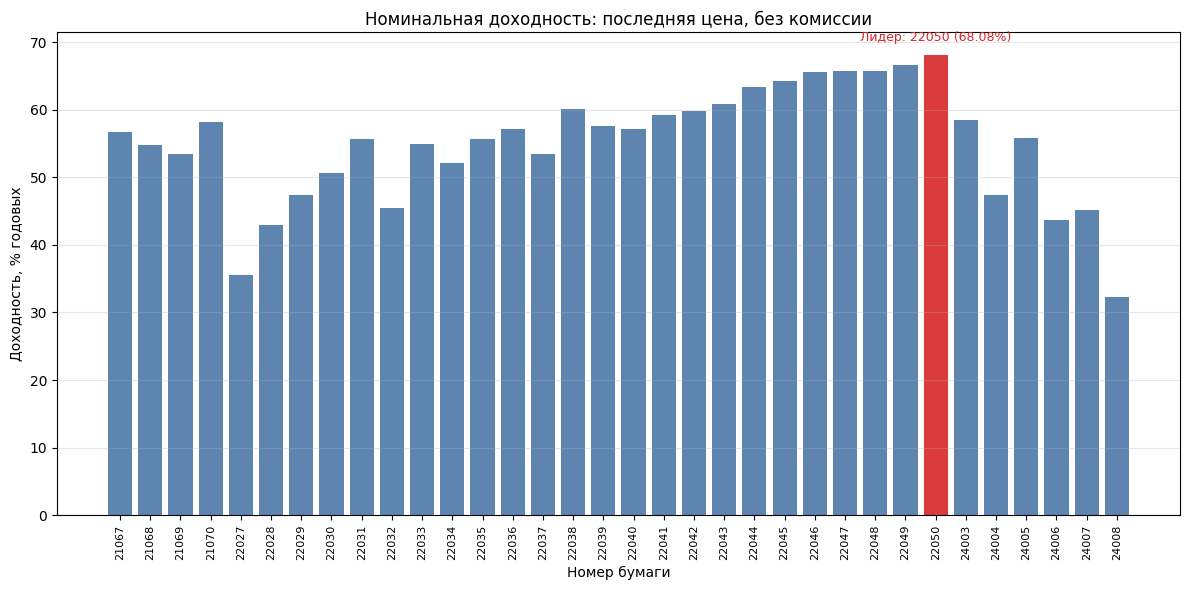

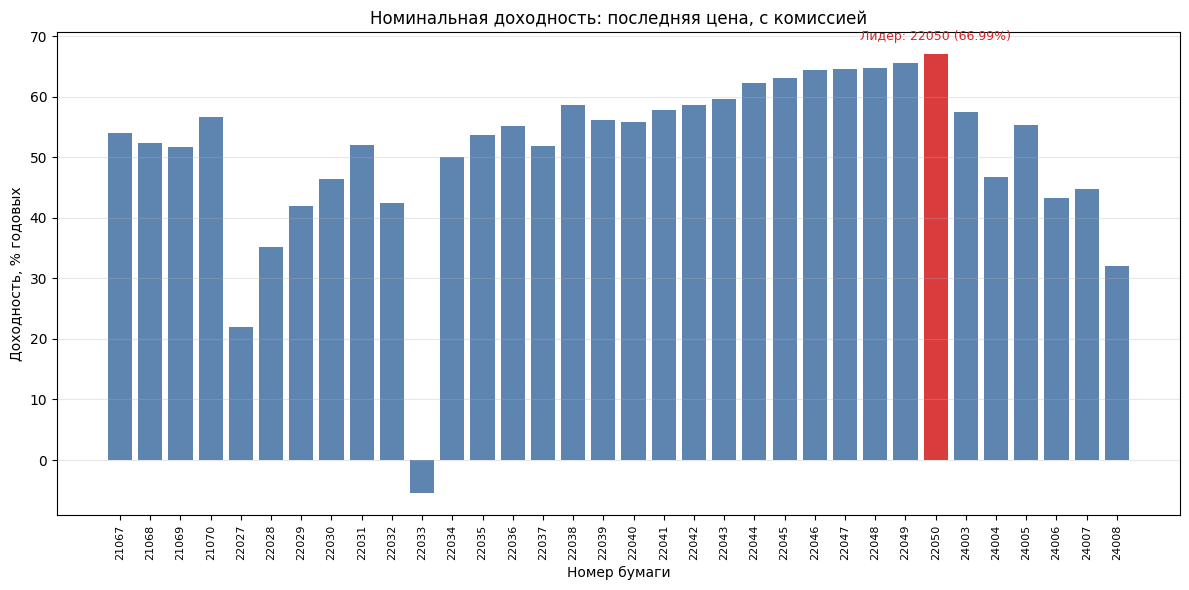

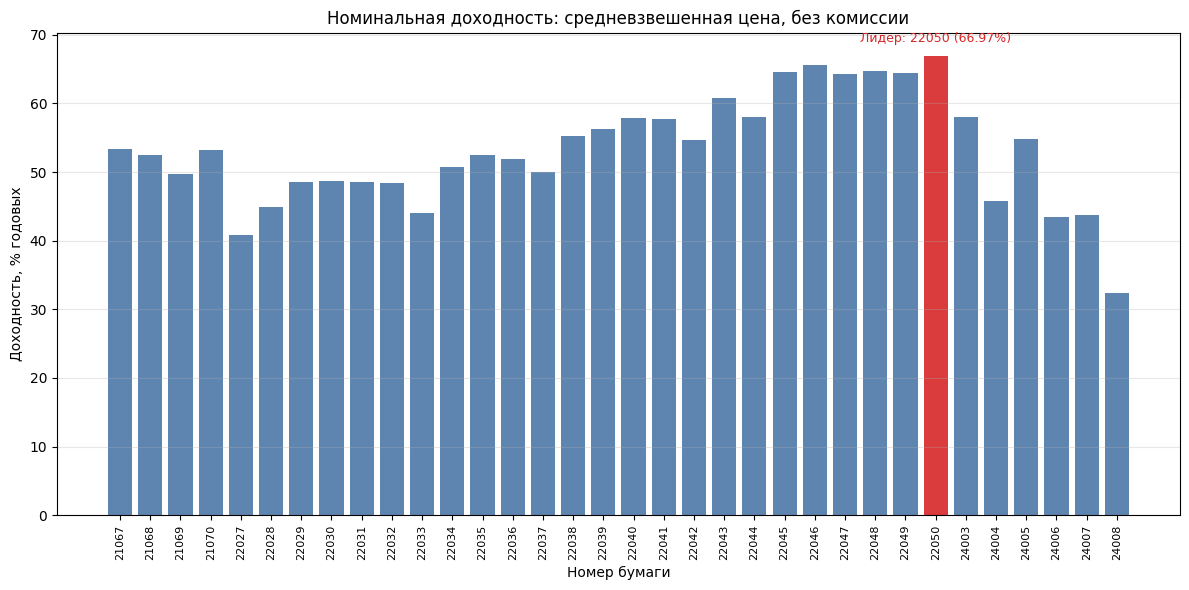

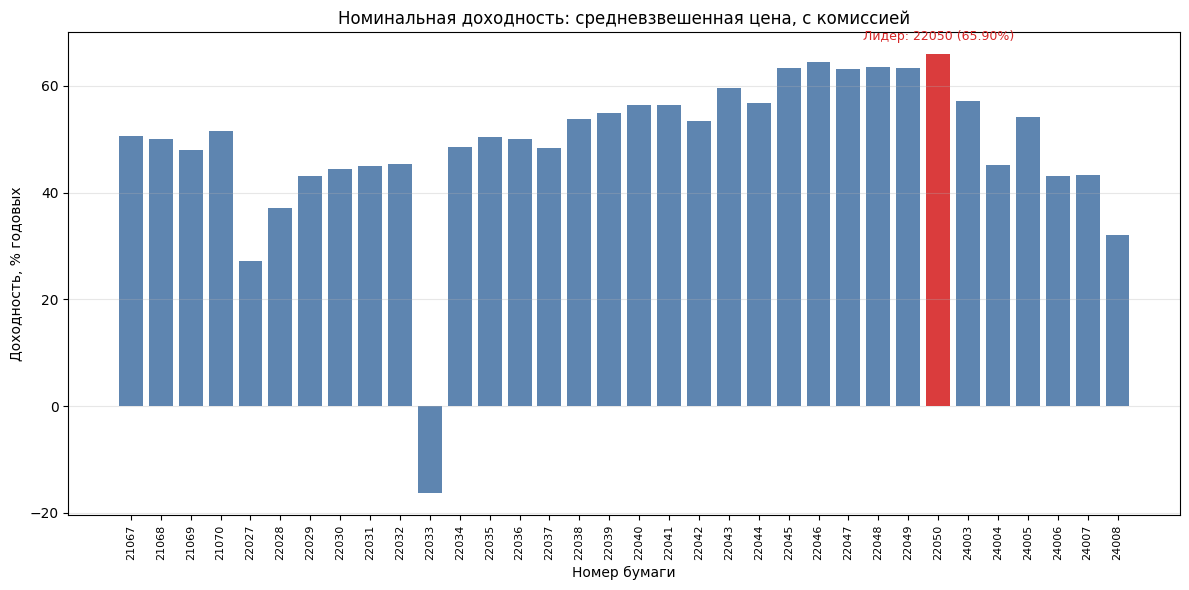

## Эффективная доходность

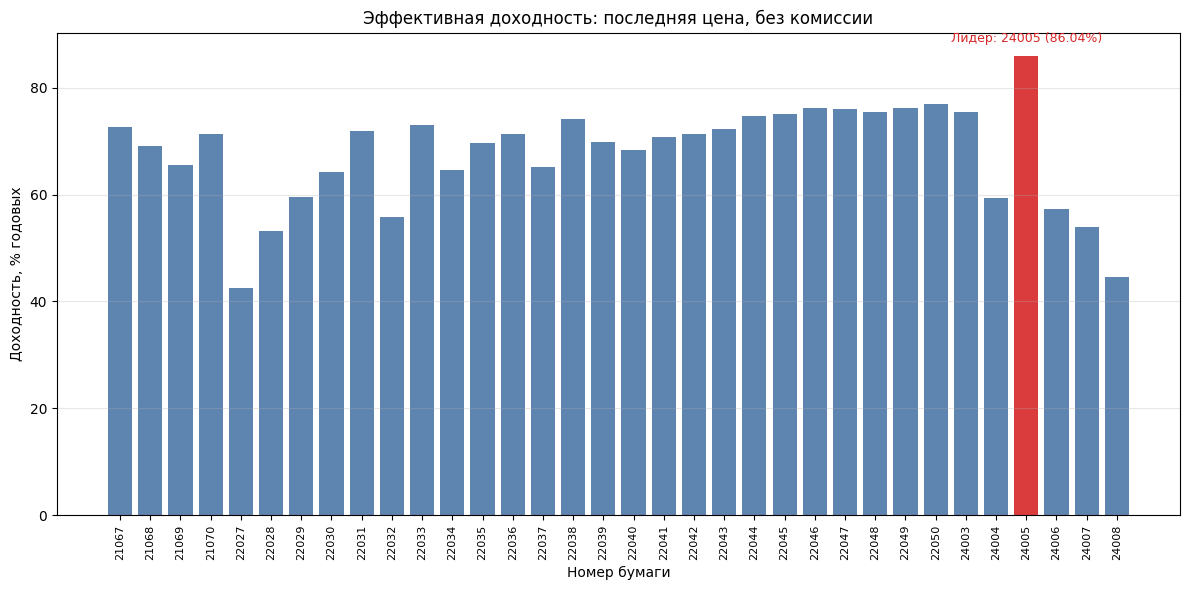

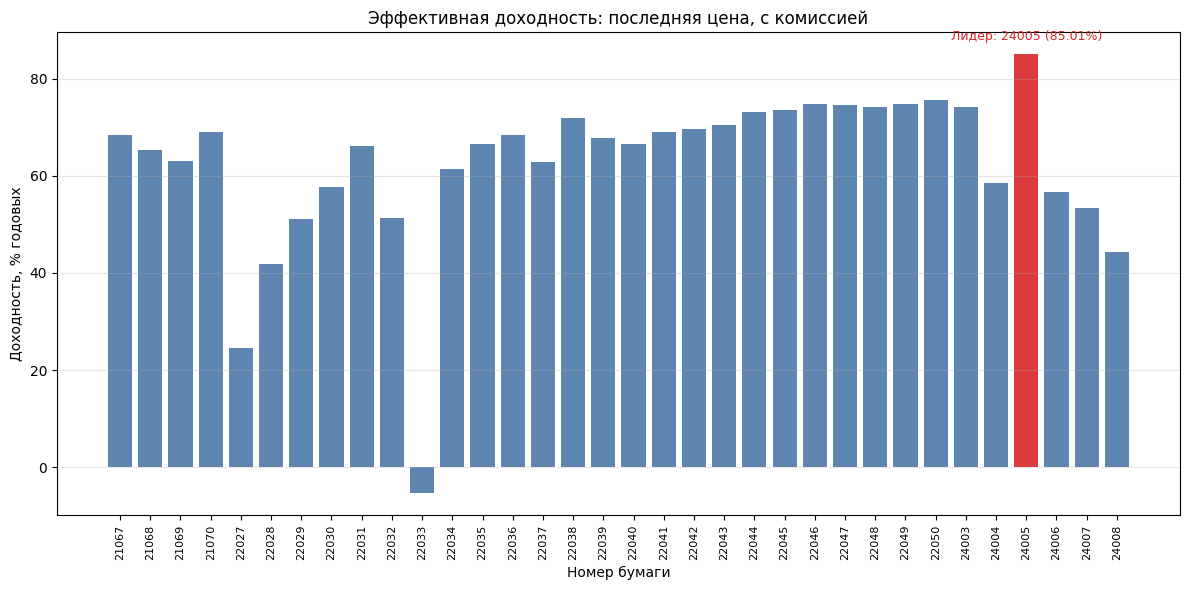

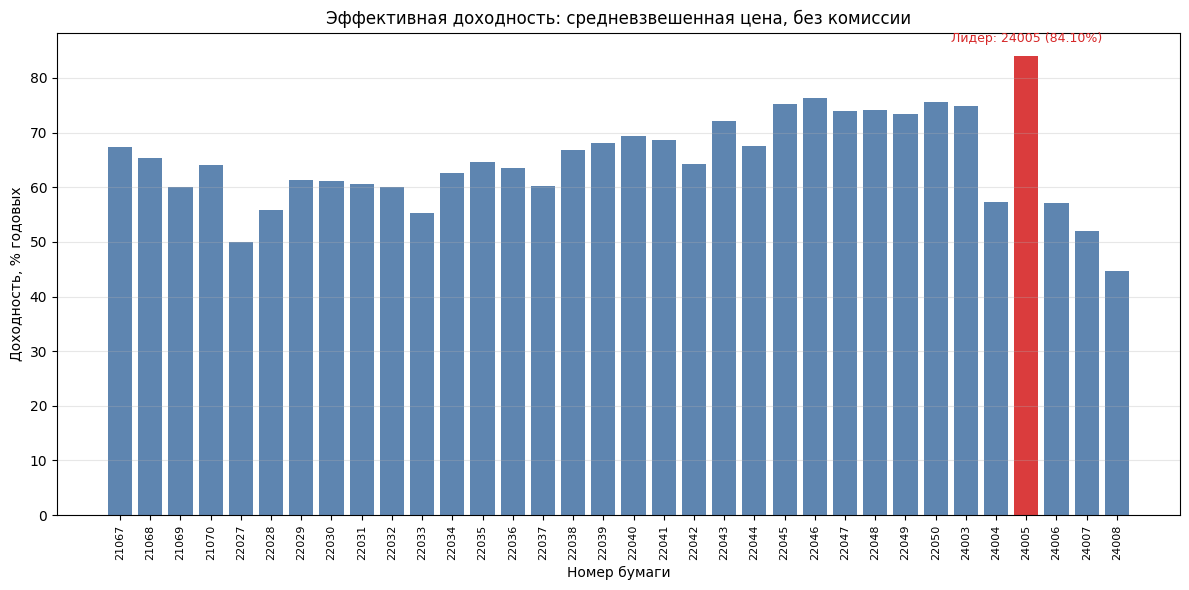

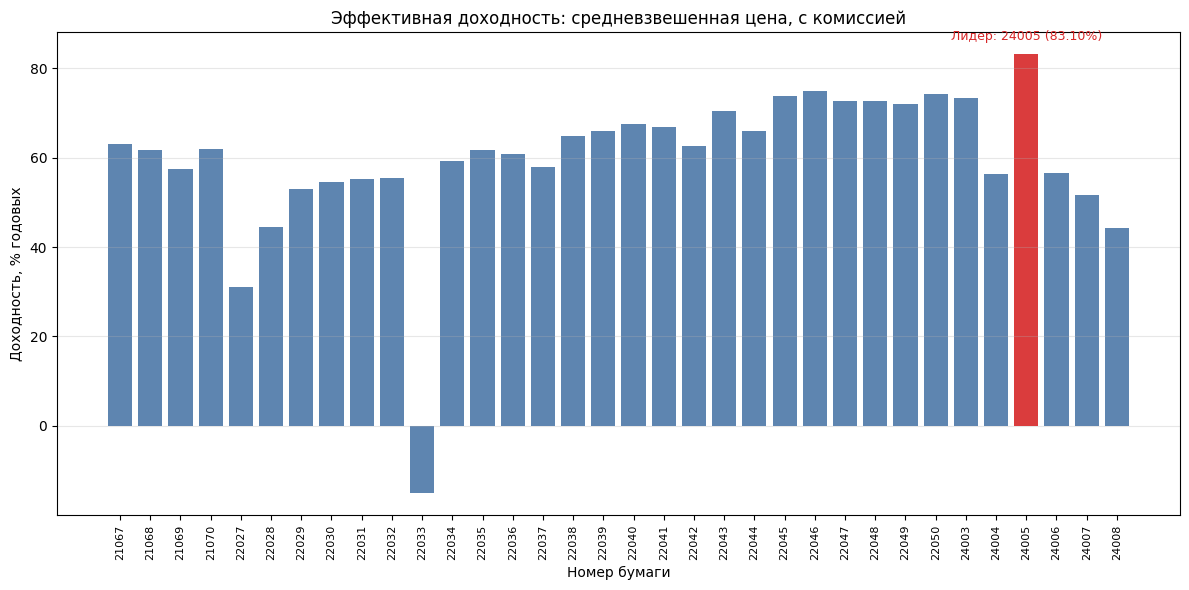

In [96]:
# =========================
# КРИВЫЕ ДОХОДНОСТИ: ВСЕ БУМАГИ
# =========================

display(Markdown("## Номинальная доходность"))
plot_curve(df_last, "nominal_yield_no_fee", "Номинальная доходность: последняя цена, без комиссии")
plot_curve(df_last, "nominal_yield_with_fee", "Номинальная доходность: последняя цена, с комиссией")
plot_curve(df_avg, "nominal_yield_no_fee", "Номинальная доходность: средневзвешенная цена, без комиссии")
plot_curve(df_avg, "nominal_yield_with_fee", "Номинальная доходность: средневзвешенная цена, с комиссией")

display(Markdown("## Эффективная доходность"))
plot_curve(df_last, "effective_yield_no_fee", "Эффективная доходность: последняя цена, без комиссии")
plot_curve(df_last, "effective_yield_with_fee", "Эффективная доходность: последняя цена, с комиссией")
plot_curve(df_avg, "effective_yield_no_fee", "Эффективная доходность: средневзвешенная цена, без комиссии")
plot_curve(df_avg, "effective_yield_with_fee", "Эффективная доходность: средневзвешенная цена, с комиссией")


## Размер выборки по классам

,Класс бумаг,Число выпусков
0,Короткие (до 3 мес.),13
1,Средние (3 мес. - 1 год),18
2,Длинные (более 1 года),3


## Номинальная доходность по классам

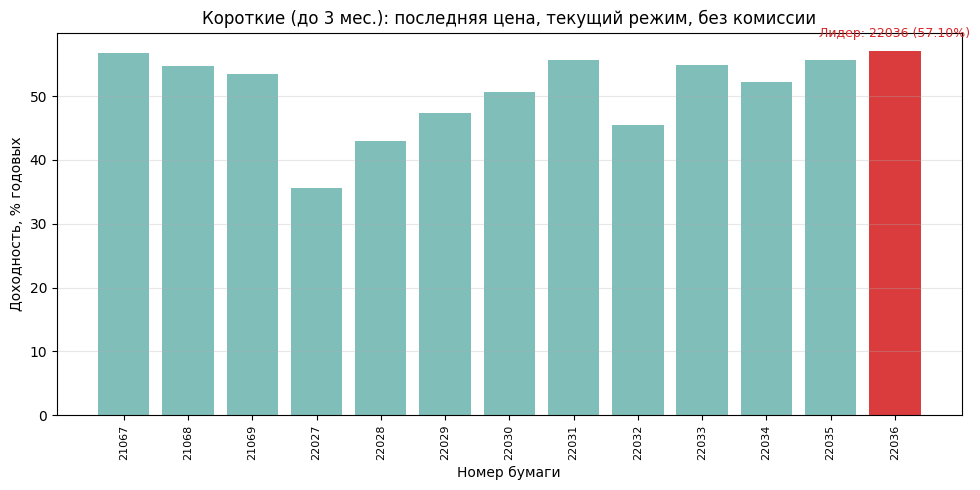

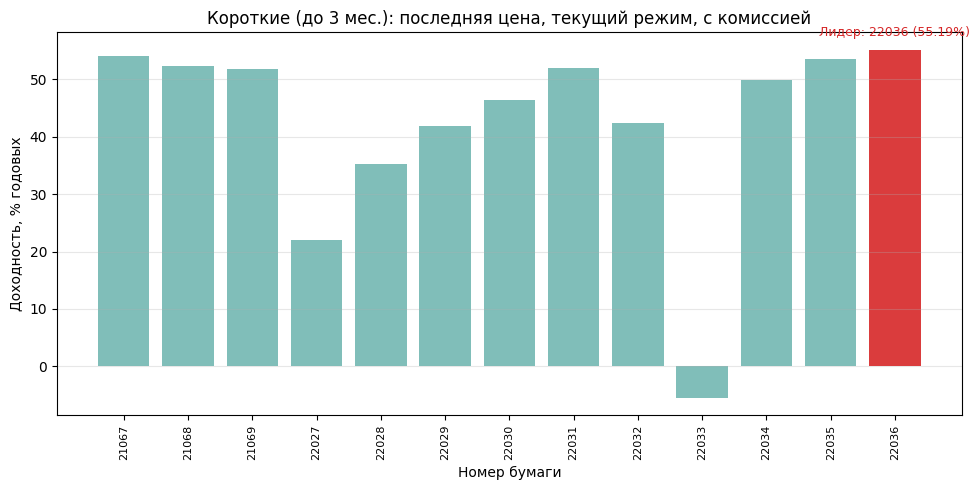

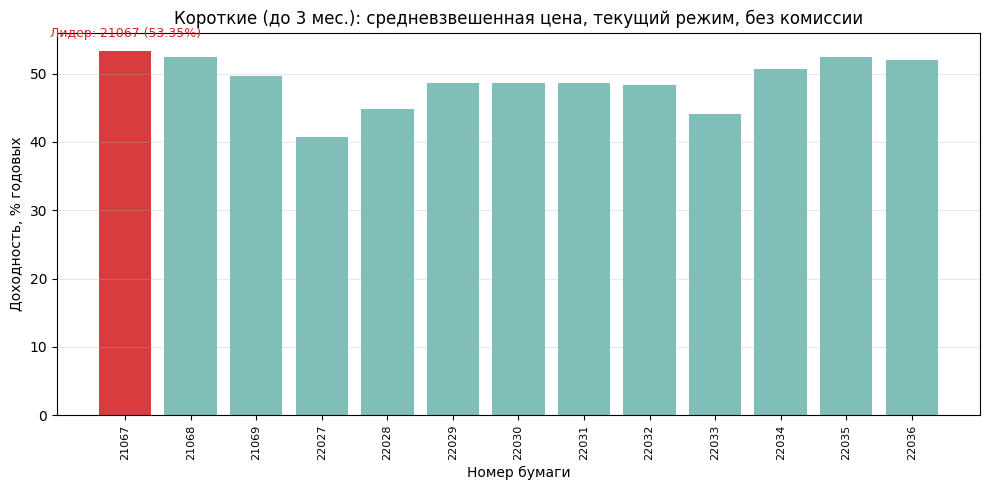

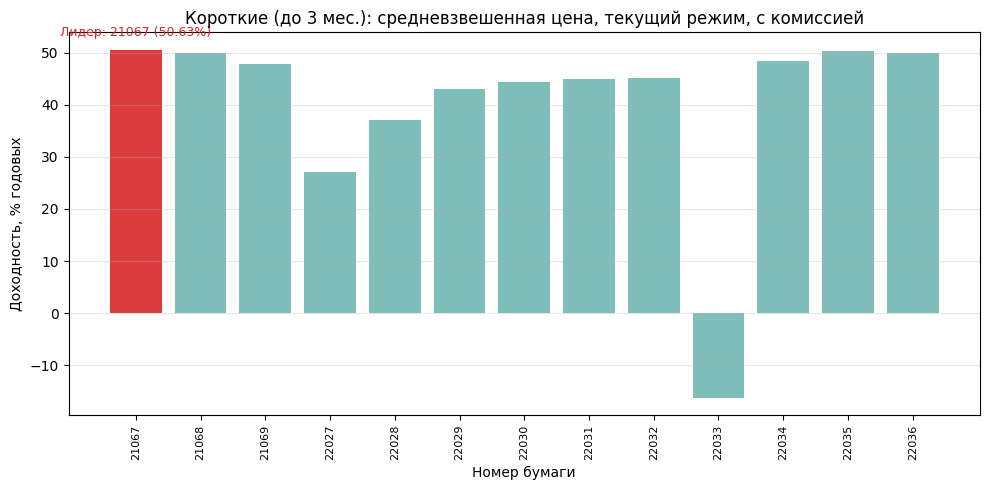

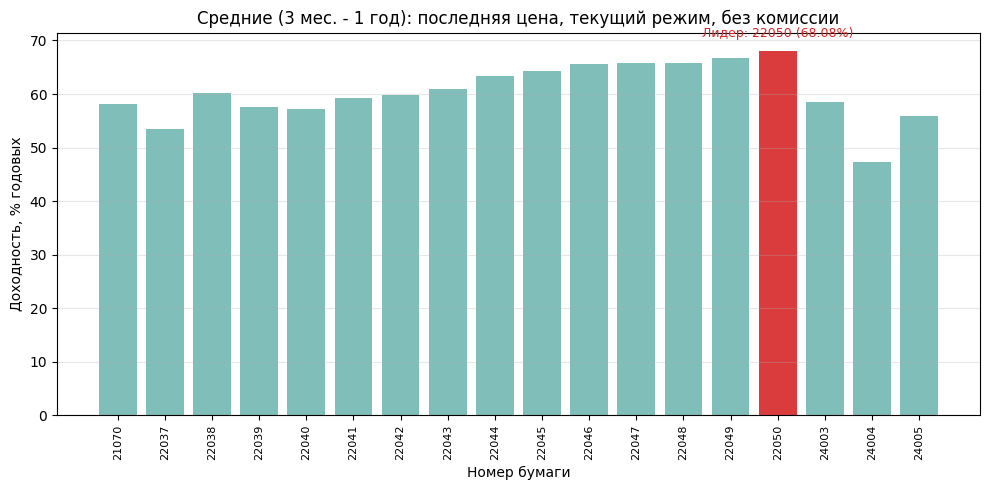

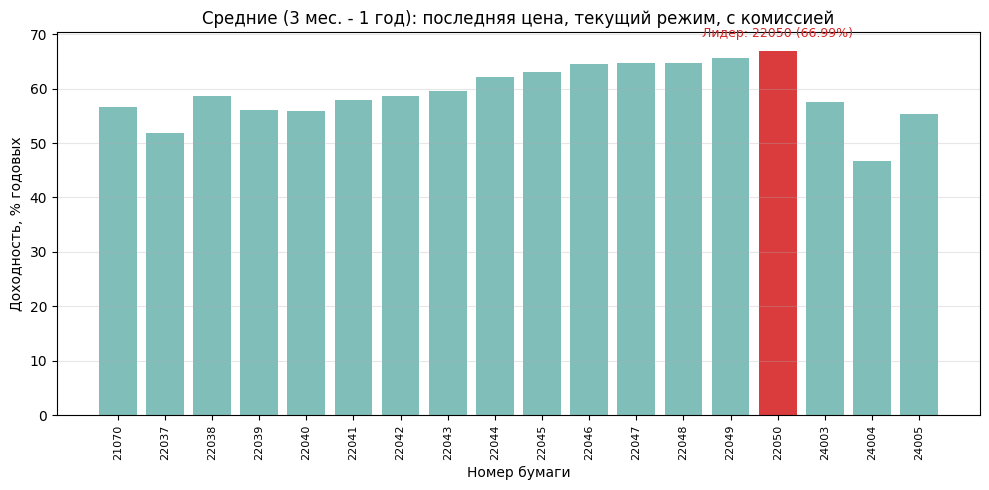

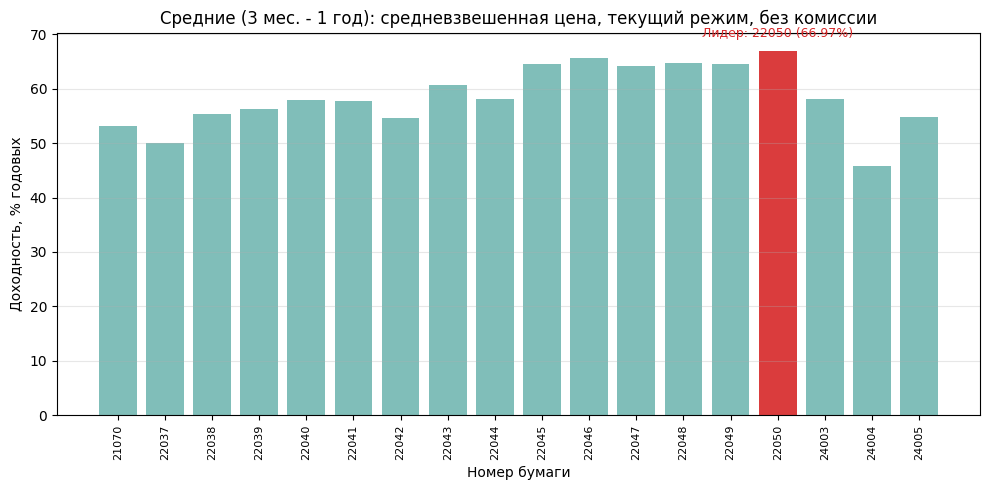

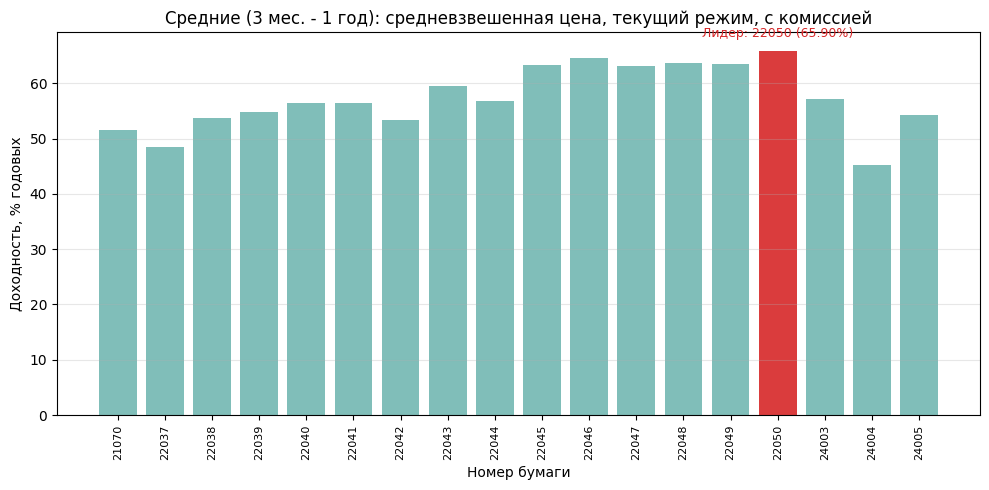

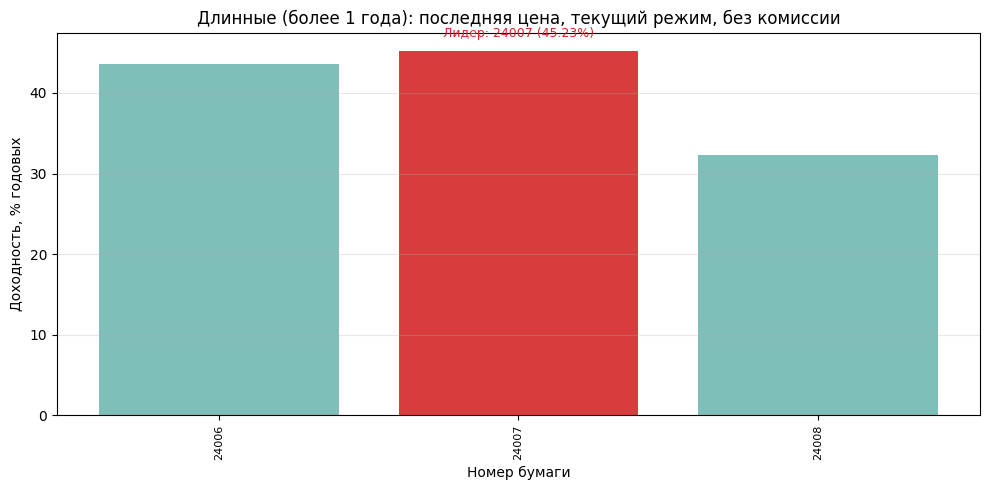

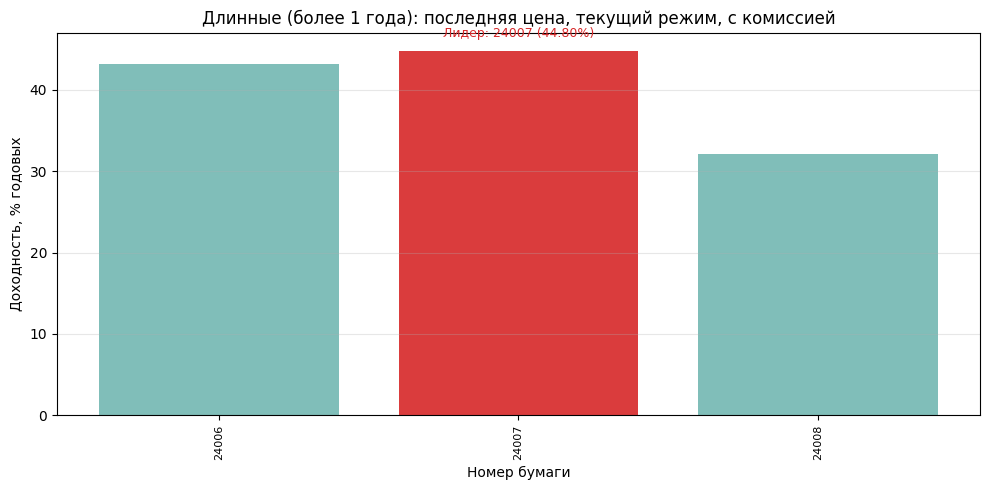

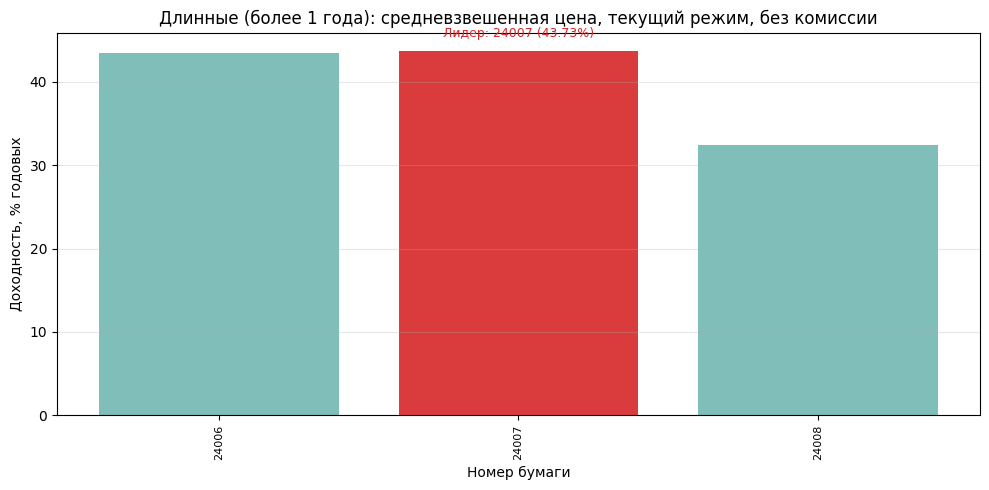

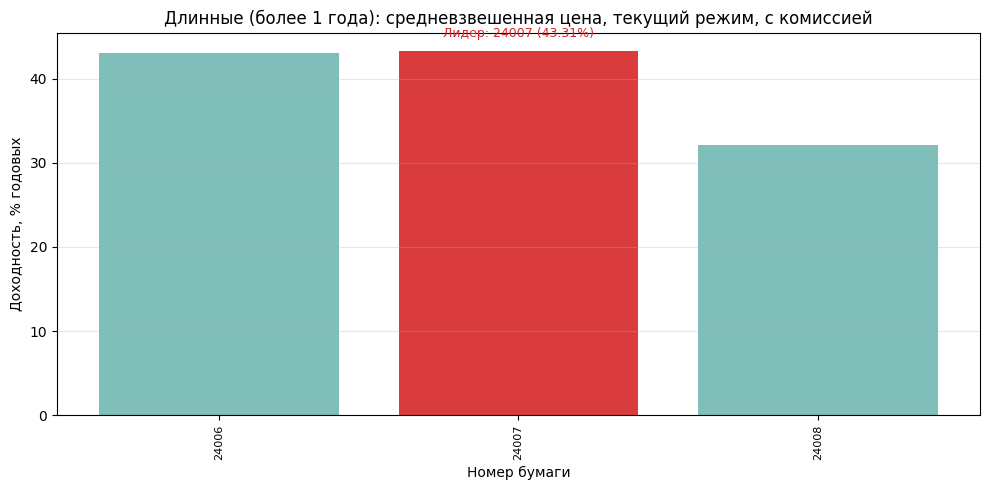

## Эффективная доходность по классам

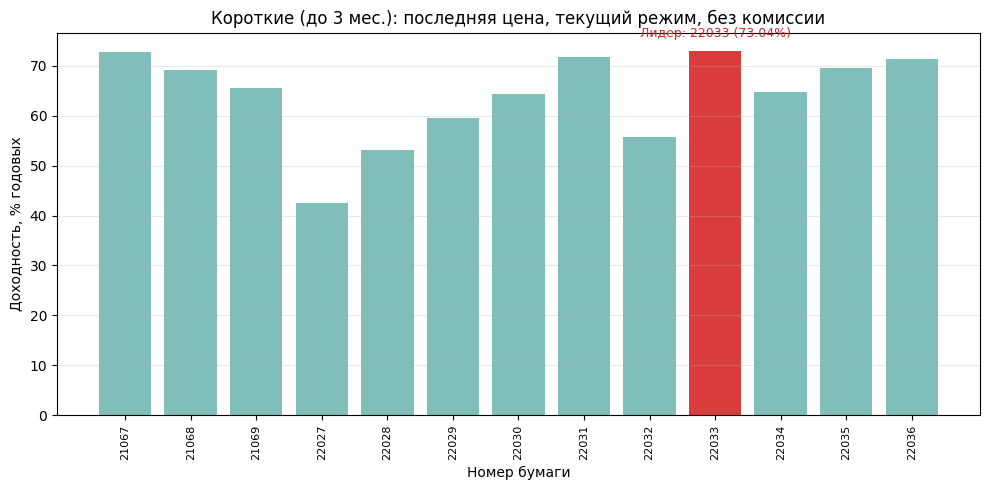

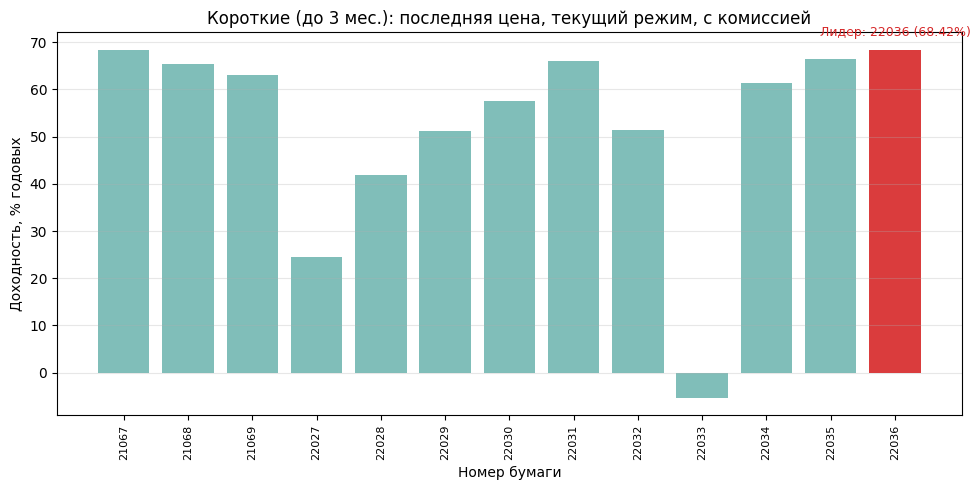

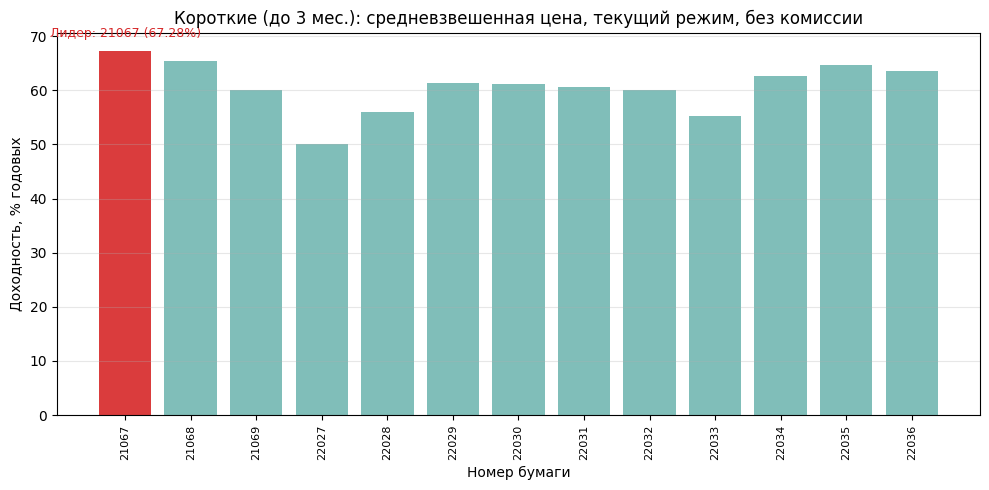

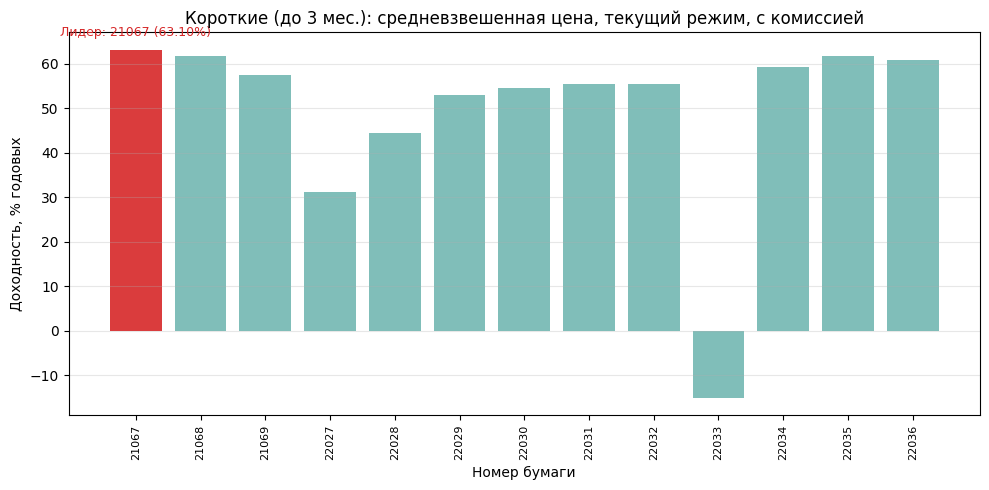

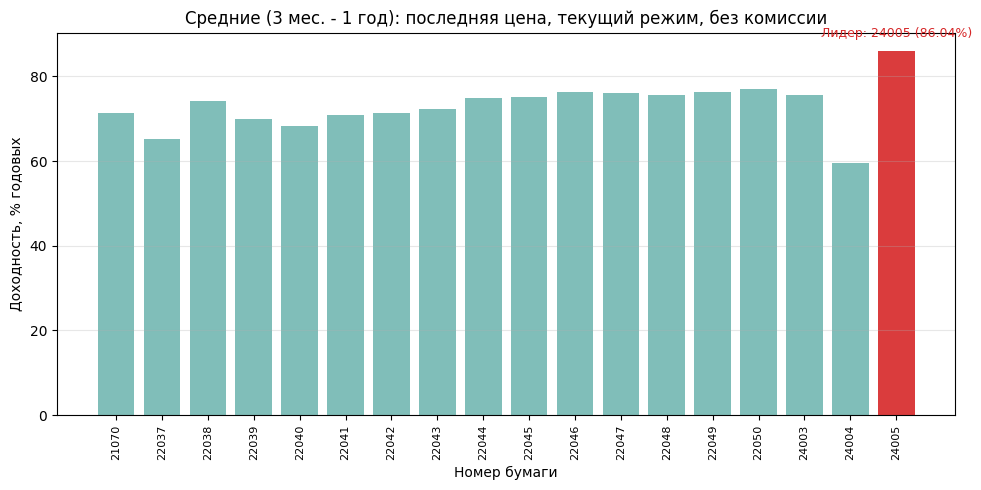

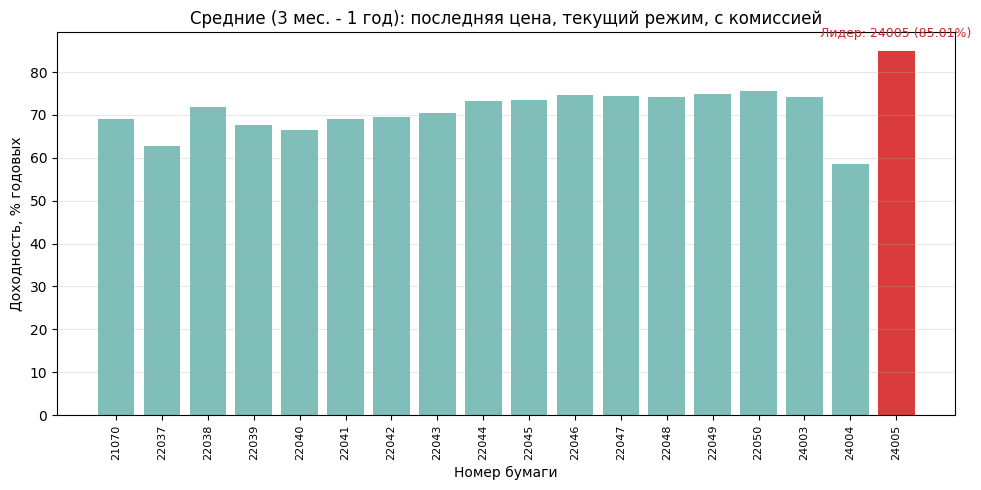

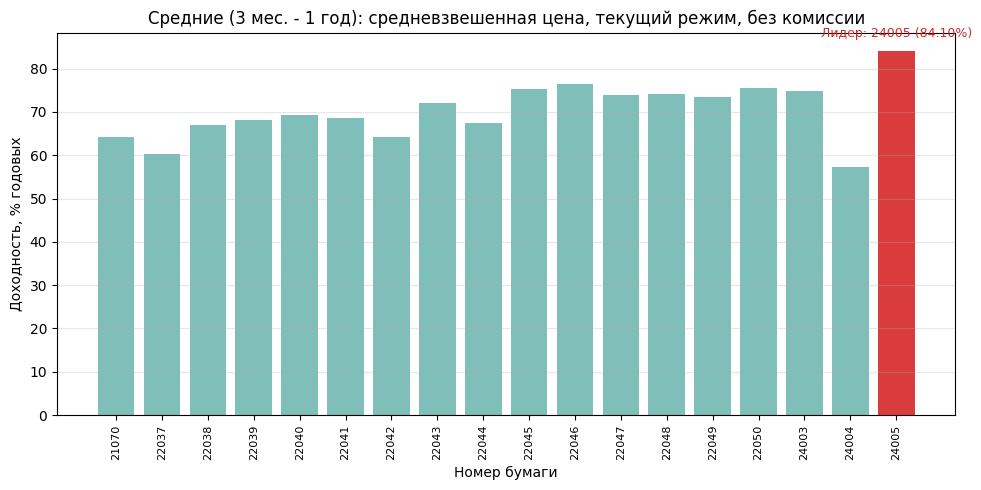

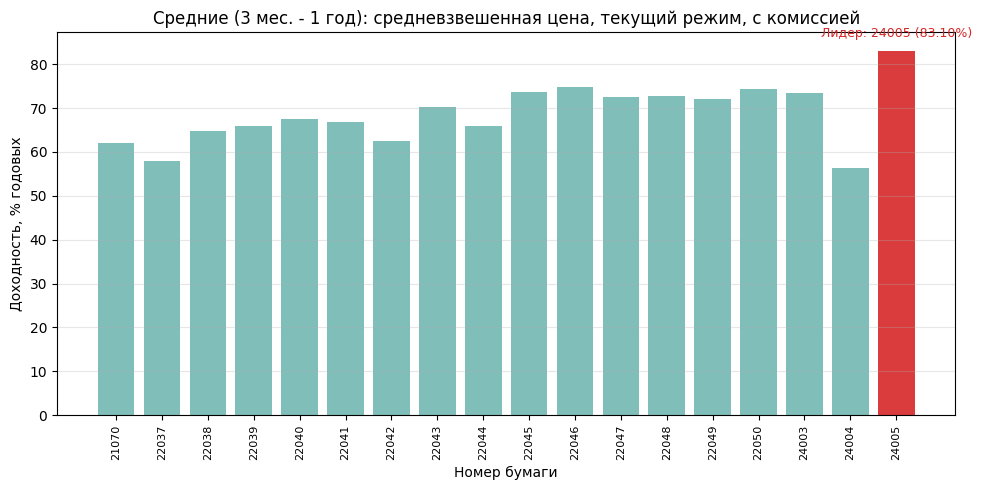

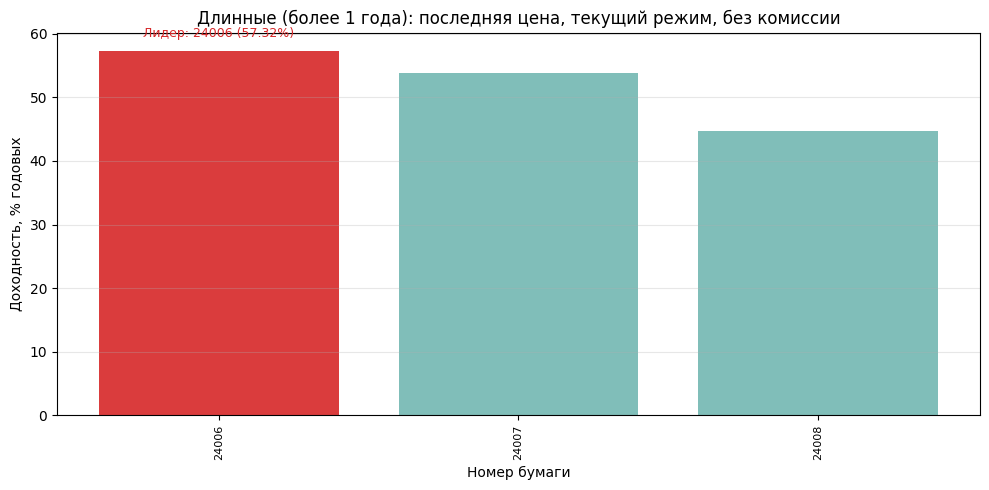

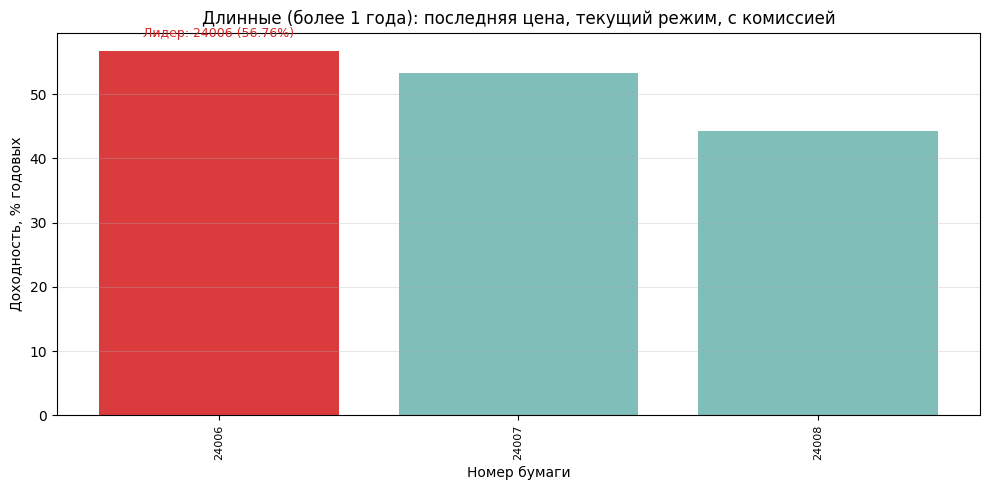

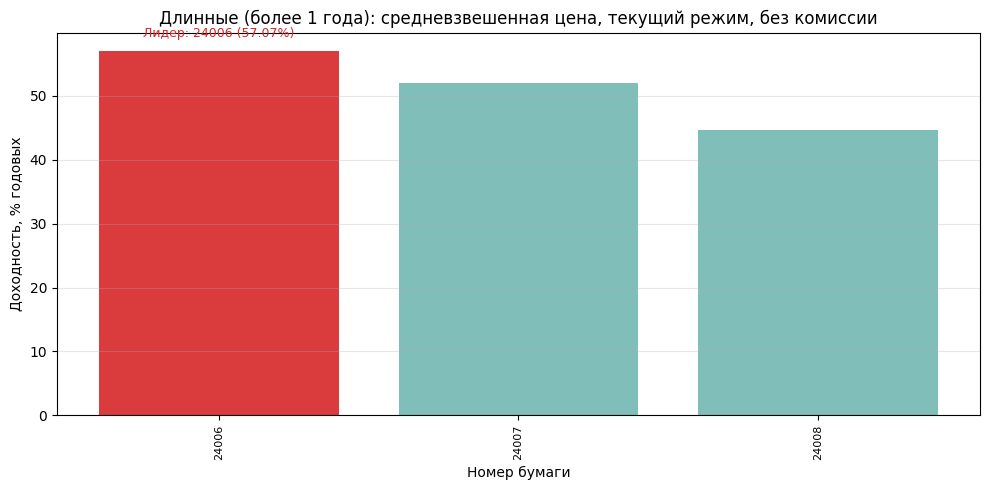

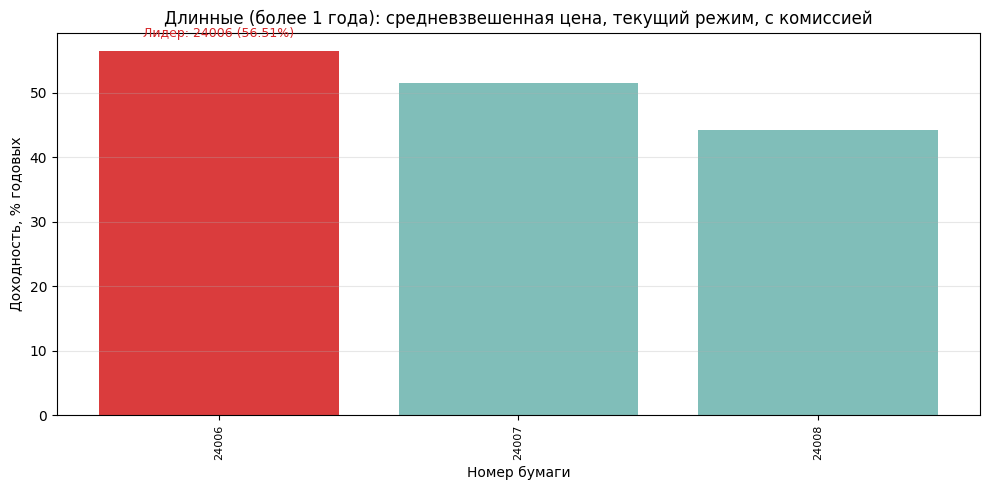

In [97]:
# =========================
# КРИВЫЕ ДОХОДНОСТИ: ПО КЛАССАМ БУМАГ
# =========================

groups = [
    "Короткие (до 3 мес.)",
    "Средние (3 мес. - 1 год)",
    "Длинные (более 1 года)",
]

display(Markdown("## Размер выборки по классам"))
display(group_count_table(df_last))

group_plot_last = df_last
group_plot_avg = df_avg
regime_label = "текущий режим"

if PRIMARY_ONLY and class_plot_is_sparse(df_last, MIN_POINTS_FOR_CLASS_PLOT):
    # display(Markdown(
    #     f"При `PRIMARY_ONLY = True` на дату `{trade_date.date()}` классы получаются слишком разреженными, "
    #     "поэтому графики ниже показаны по всему рынку на той же дате."
    # ))
    display(group_count_table(df_last_all_market))
    group_plot_last = df_last_all_market
    group_plot_avg = df_avg_all_market
    regime_label = "весь рынок"

display(Markdown("## Номинальная доходность по классам"))
for g in groups:
    plot_curve_by_group(group_plot_last, "nominal_yield_no_fee", g, f"последняя цена, {regime_label}", "без комиссии")
    plot_curve_by_group(group_plot_last, "nominal_yield_with_fee", g, f"последняя цена, {regime_label}", "с комиссией")
    plot_curve_by_group(group_plot_avg, "nominal_yield_no_fee", g, f"средневзвешенная цена, {regime_label}", "без комиссии")
    plot_curve_by_group(group_plot_avg, "nominal_yield_with_fee", g, f"средневзвешенная цена, {regime_label}", "с комиссией")

display(Markdown("## Эффективная доходность по классам"))
for g in groups:
    plot_curve_by_group(group_plot_last, "effective_yield_no_fee", g, f"последняя цена, {regime_label}", "без комиссии")
    plot_curve_by_group(group_plot_last, "effective_yield_with_fee", g, f"последняя цена, {regime_label}", "с комиссией")
    plot_curve_by_group(group_plot_avg, "effective_yield_no_fee", g, f"средневзвешенная цена, {regime_label}", "без комиссии")
    plot_curve_by_group(group_plot_avg, "effective_yield_with_fee", g, f"средневзвешенная цена, {regime_label}", "с комиссией")


## Сравнение номинальной и эффективной доходности

### Короткие (до 3 мес.)

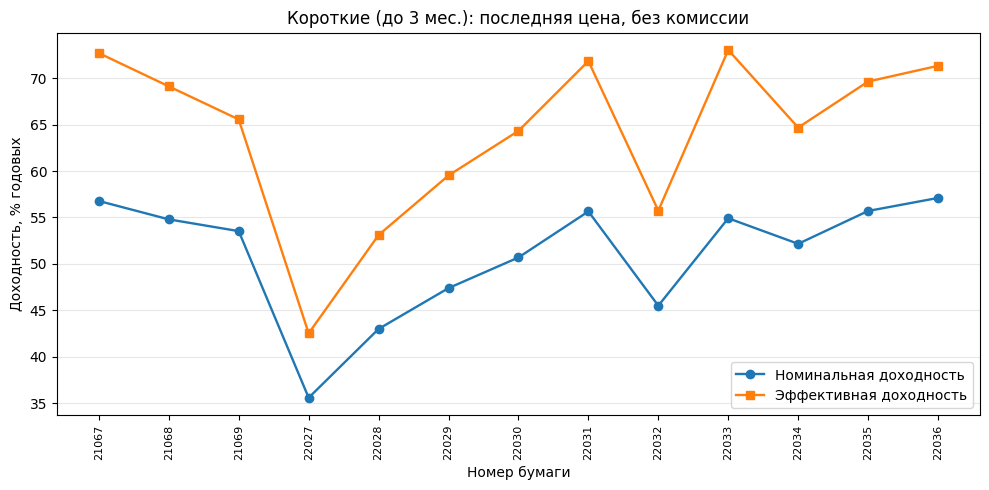

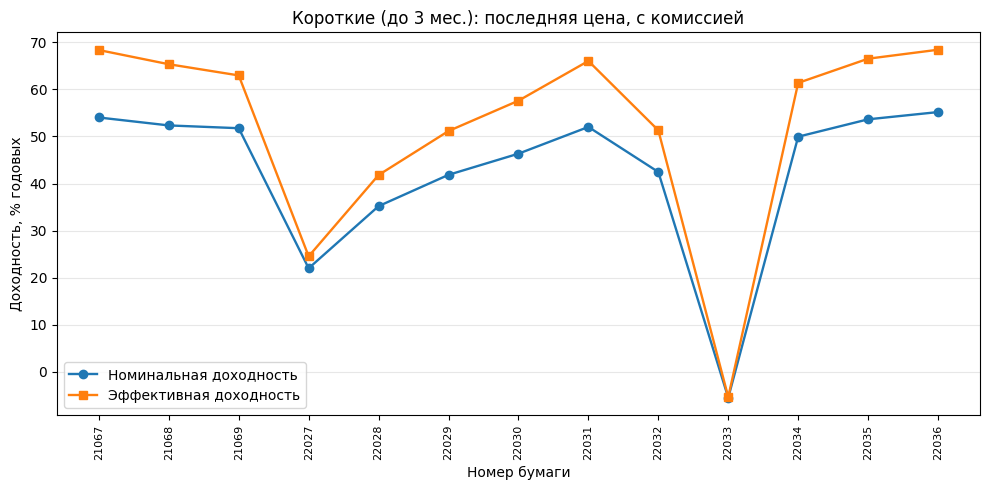

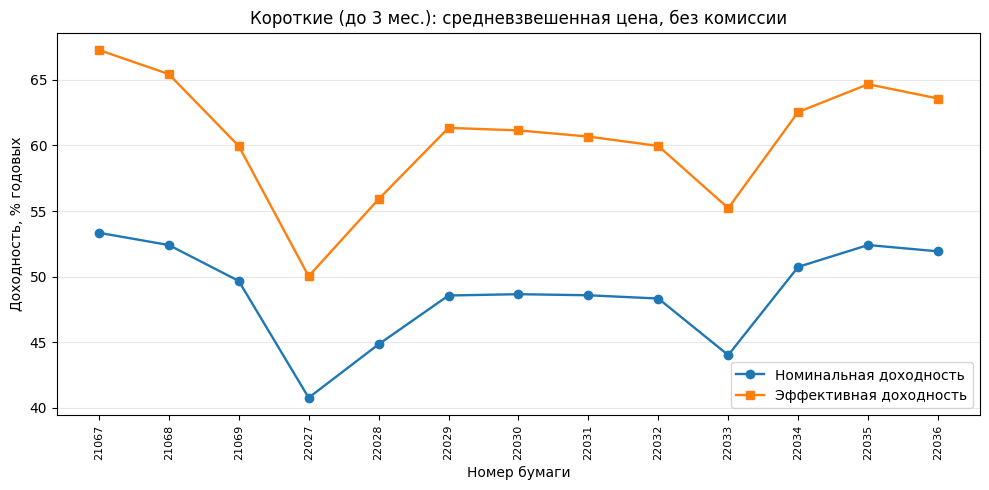

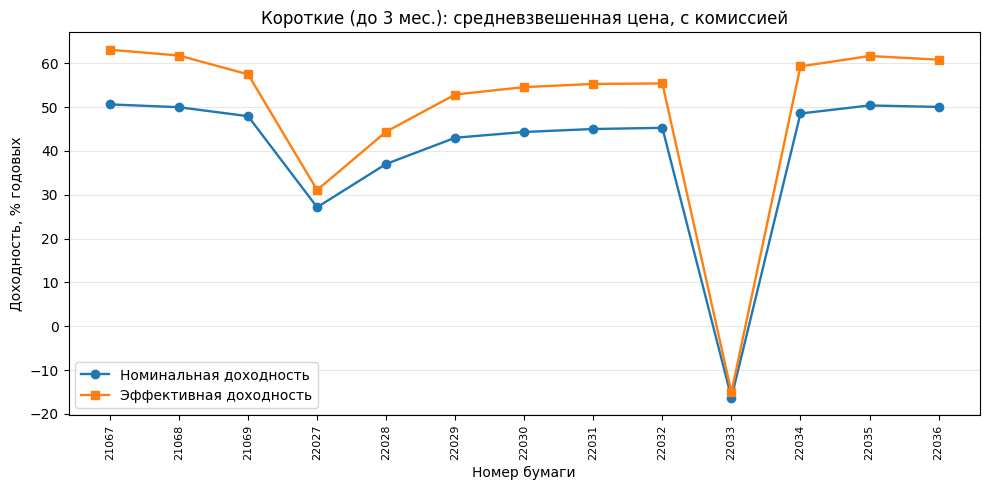

### Средние (3 мес. - 1 год)

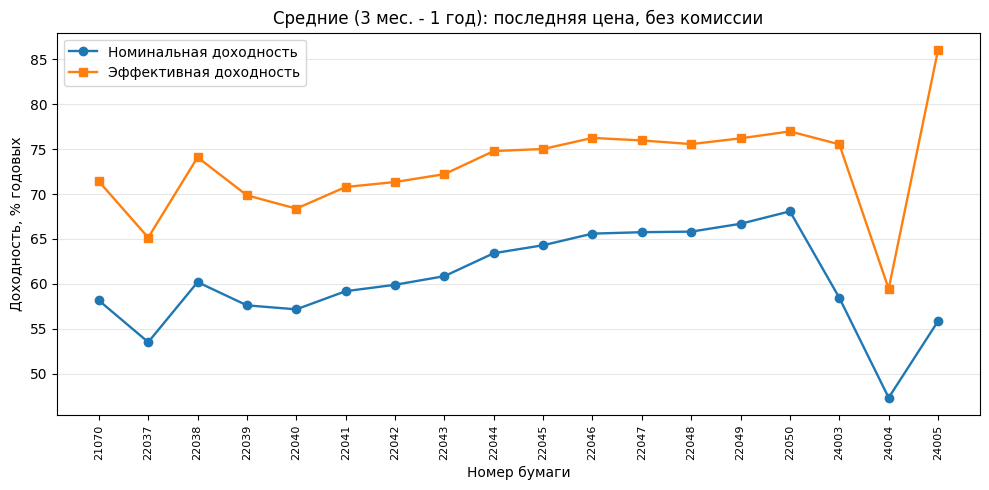

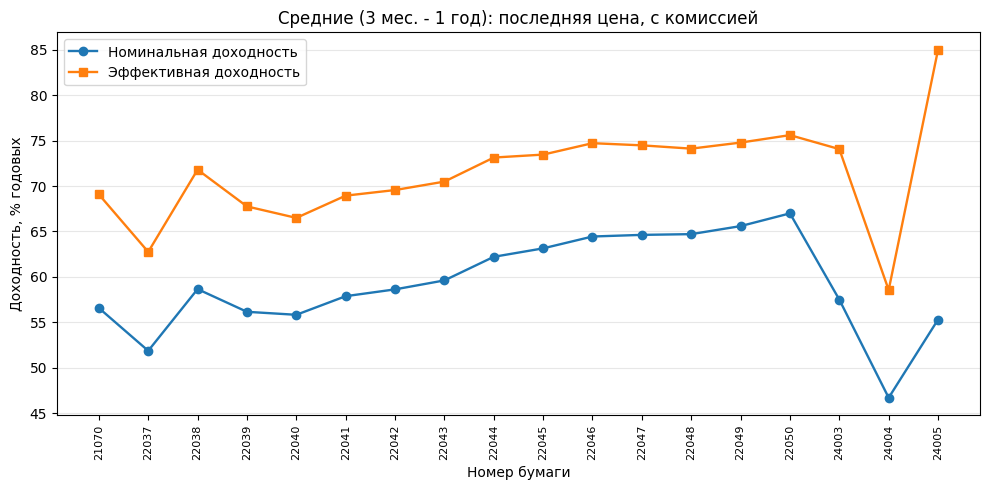

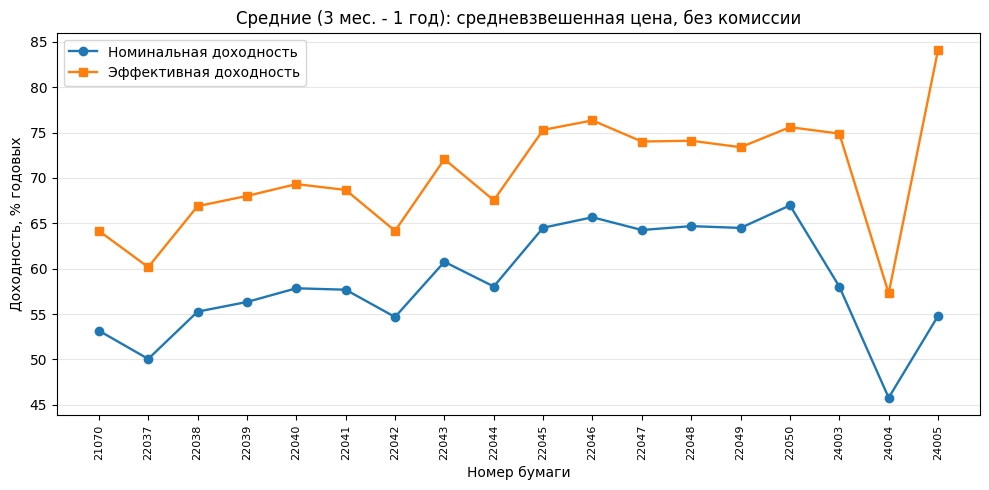

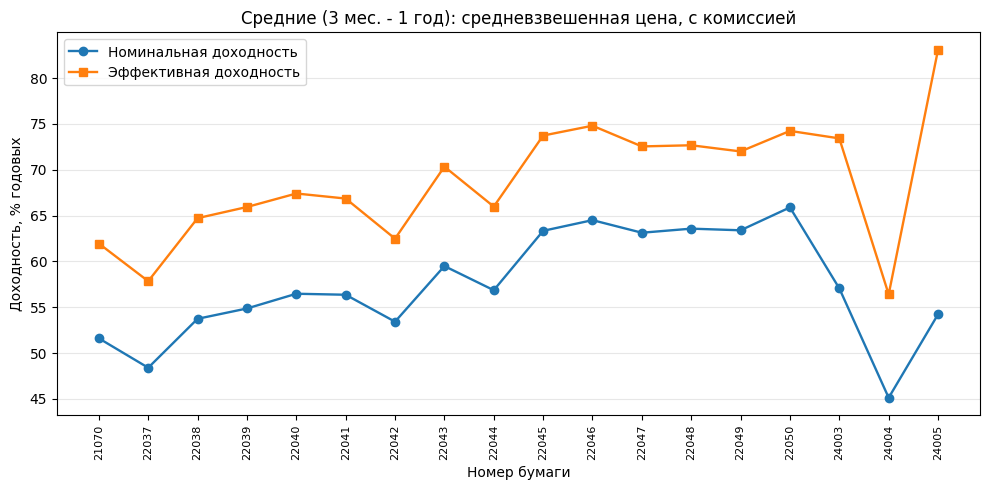

### Длинные (более 1 года)

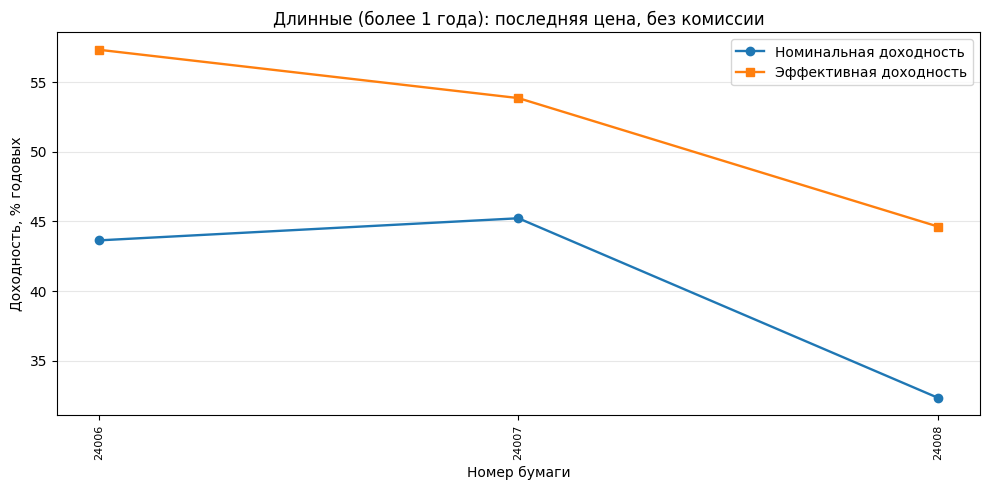

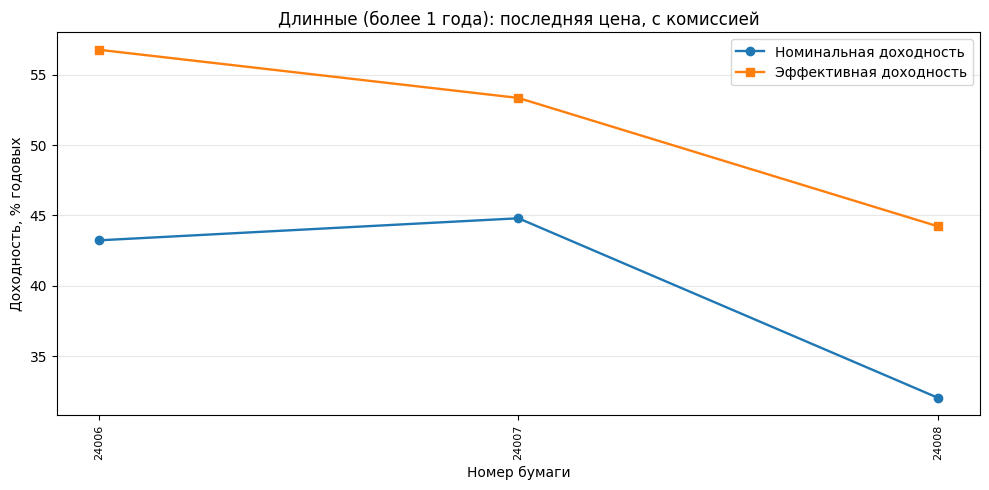

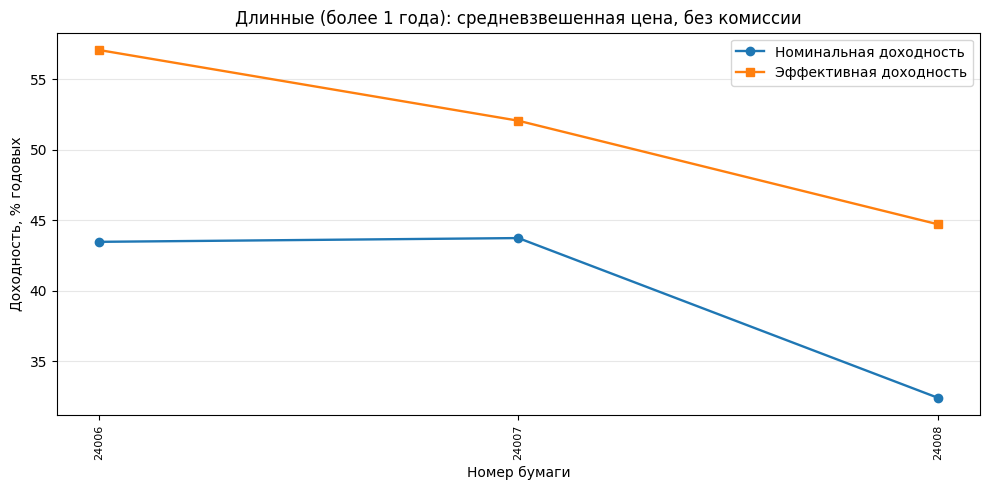

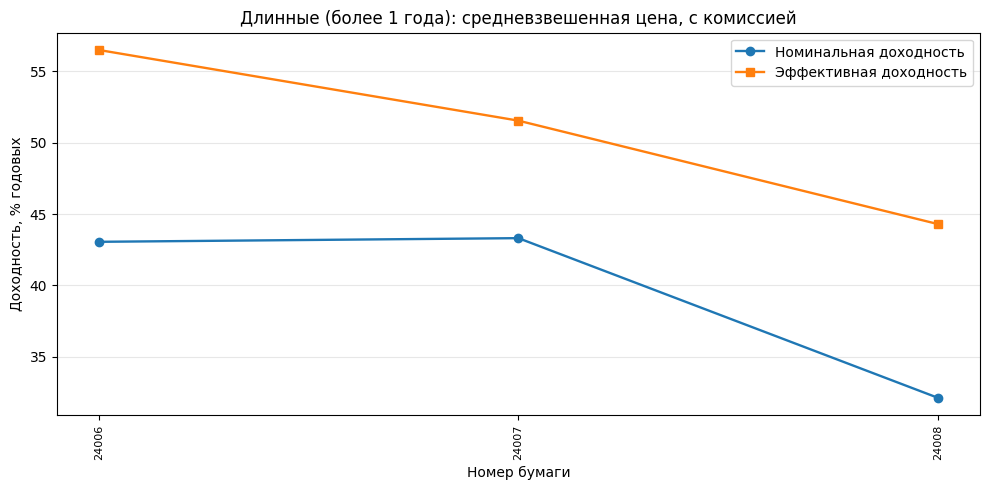

In [98]:
# =========================
# СРАВНЕНИЕ НОМИНАЛЬНОЙ И ЭФФЕКТИВНОЙ ДОХОДНОСТИ ПО КЛАССАМ
# =========================

def plot_nominal_vs_effective_by_group(
    data: pd.DataFrame,
    group_name: str,
    nominal_metric: str,
    effective_metric: str,
    title: str,
):
    subset = (
        data[data["group"] == group_name]
        .dropna(subset=[nominal_metric, effective_metric])
        .sort_values("security")
        .copy()
    )

    if subset.empty:
        display(Markdown(f"Для группы **{group_name}** нет данных для графика **{title}**."))
        return

    x = np.arange(len(subset))

    plt.figure(figsize=(max(10, len(subset) * 0.35), 5))
    plt.plot(x, subset[nominal_metric], marker="o", linewidth=1.7, label="Номинальная доходность")
    plt.plot(x, subset[effective_metric], marker="s", linewidth=1.7, label="Эффективная доходность")
    plt.xticks(x, subset["security"].astype(str), rotation=90, fontsize=8)
    plt.xlabel("Номер бумаги")
    plt.ylabel("Доходность, % годовых")
    plt.title(f"{group_name}: {title}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()


comparison_specs = [
    (group_plot_last, "nominal_yield_no_fee", "effective_yield_no_fee", "последняя цена, без комиссии"),
    (group_plot_last, "nominal_yield_with_fee", "effective_yield_with_fee", "последняя цена, с комиссией"),
    (group_plot_avg, "nominal_yield_no_fee", "effective_yield_no_fee", "средневзвешенная цена, без комиссии"),
    (group_plot_avg, "nominal_yield_with_fee", "effective_yield_with_fee", "средневзвешенная цена, с комиссией"),
]

display(Markdown("## Сравнение номинальной и эффективной доходности"))
for g in groups:
    display(Markdown(f"### {g}"))
    for data, nominal_metric, effective_metric, title in comparison_specs:
        plot_nominal_vs_effective_by_group(data, g, nominal_metric, effective_metric, title)


In [99]:
def compact_conclusion(df: pd.DataFrame, metric: str, label: str):
    winners = best_by_group(df, metric)
    display(Markdown(f"### {label}"))

    # if winners.empty:
    #     display(Markdown("Данных для краткого вывода нет."))
    #     return

    for _, row in winners.iterrows():
        display(Markdown(
            f"- **{row['group']}**: выпуск **{int(row['security'])}**, "
            f"доходность **{row[metric]:.2f}%** годовых, "
            f"до погашения **{int(row['days_to_maturity'])}** дней, "
            f"чистая цена **{row['price_clean']:.2f}**, НКД **{row['accrued_coupon']:.2f}**, "
        ))


compact_conclusion(df_last, "effective_yield_no_fee", "Вывод по последней цене без комиссии")
compact_conclusion(df_last, "effective_yield_with_fee", "Вывод по последней цене с комиссией")
compact_conclusion(df_avg, "effective_yield_no_fee", "Вывод по средневзвешенной цене без комиссии")
compact_conclusion(df_avg, "effective_yield_with_fee", "Вывод по средневзвешенной цене с комиссией")

### Вывод по последней цене без комиссии

- **Короткие (до 3 мес.)**: выпуск **22033**, доходность **73.04%** годовых, до погашения **2** дней, чистая цена **99.70**, НКД **0.00**, 

- **Средние (3 мес. - 1 год)**: выпуск **24005**, доходность **86.04%** годовых, до погашения **289** дней, чистая цена **86.83**, НКД **19.74**, 

- **Длинные (более 1 года)**: выпуск **24006**, доходность **57.32%** годовых, до погашения **499** дней, чистая цена **85.34**, НКД **8.76**, 

### Вывод по последней цене с комиссией

...

- **Длинные (более 1 года)**: выпуск **24006**, доходность **57.07%** годовых, до погашения **499** дней, чистая цена **85.49**, НКД **8.76**, 

### Вывод по средневзвешенной цене с комиссией

- **Короткие (до 3 мес.)**: выпуск **21067**, доходность **63.10%** годовых, до погашения **51** дней, чистая цена **93.06**, НКД **0.00**, 

- **Средние (3 мес. - 1 год)**: выпуск **24005**, доходность **83.10%** годовых, до погашения **289** дней, чистая цена **87.46**, НКД **19.74**, 

- **Длинные (более 1 года)**: выпуск **24006**, доходность **56.51%** годовых, до погашения **499** дней, чистая цена **85.49**, НКД **8.76**, 



Если при `PRIMARY_ONLY = True` в классах слишком мало выпусков, раздел с графиками по классам автоматически строится по всему рынку на той же дате.